# SLA Violation Prediction using Graph Neural Networks

**Predicting SLA Violations in Business Processes with BPMN-based GNNs**

---

**Pipeline**: `Event Log → SLA Labeling → Process Mining → Graph Construction → GNN → Prediction → Business Insights`

This notebook implements an end-to-end pipeline that:
1. Loads business process event logs (real or synthetic)
2. Labels each case by SLA compliance (on-time vs violated)
3. Discovers the process model (BPMN) via process mining
4. Converts each case into a directed graph
5. Trains a Graph Convolutional Network (GCN) to predict SLA violations
6. Evaluates model performance with comprehensive metrics
7. Demonstrates business use cases (early warning, bottleneck detection)

**Runs on CPU or CUDA** — device is auto-detected. All experiments are fully seeded for reproducibility.


## 7. Tài liệu Tham khảo

| # | Tác giả | Năm | Tiêu đề | Venue | Đóng góp cho đề xuất |
|:---:|---|:---:|---|---|---|
| [1] | Kipf & Welling | 2017 | [Semi-supervised classification with GCN](https://arxiv.org/abs/1609.02907) | ICLR | Kiến trúc GCN sử dụng trong Mục 2.4 |
| [2] | Teinemaa et al. | 2019 | [Outcome-oriented PPM: Review and benchmark](https://doi.org/10.1145/3301300) | ACM TKDD | Giao thức đánh giá train/val/test (Mục 2.6) |
| [3] | van Dongen | 2012 | [BPI Challenge 2012](https://doi.org/10.4121/uuid:3926db30-f712-4394-aebc-75976070e91f) | 4TU | Tập dữ liệu benchmark (Mục 3) |
| [5] | Camargo et al. | 2019 | [Learning accurate LSTM models of BPs](https://doi.org/10.1007/978-3-030-26619-6_19) | BPM | Nguồn gốc `time_since_start` & `time_since_prev` (Mục 2.2) |
| [7] | Veličković et al. | 2018 | [Graph attention networks](https://arxiv.org/abs/1710.10903) | ICLR | GAT — hướng phát triển tương lai (Mục 5) |
| [8] | Fey & Lenssen | 2019 | [Fast GRL with PyTorch Geometric](https://arxiv.org/abs/1903.02428) | ICLR WS | Framework cài đặt GCN |
| [9] | Wang & Damiani | 2025 | [Time-aware & transition-semantic GNN for PBPM](https://arxiv.org/abs/2508.09527) | arXiv | Mở rộng trực tiếp: GCN prefix + time decay |
| [10] | Lischka et al. | 2025 | [DFG go PPM with GNN](https://arxiv.org/abs/2503.03197) | arXiv | **Cùng DFG + GNN approach**, so sánh đa kiến trúc |
| [11] | Dissegna & Di Francescomarino | 2025 | [GNN for PPM: Review & Benchmark](https://doi.org/10.1007/978-3-031-78666-2_3) | BPM 2024 | GNN đạt +10% accuracy so với LSTM/Transformer |
| [12] | Rama-Maneiro et al. | 2024 | [Embedding GCN in RNN for PPM](https://doi.org/10.1109/TKDE.2023.3286017) | IEEE TKDE | GCN > LSTM — củng cố lựa chọn GCN |
| [13] | Chiorrini et al. | 2023 | [Multi-perspective instance graphs for next activity prediction](https://doi.org/10.1007/s10844-023-00777-1) | JIIS | Hướng mở rộng: đồ thị đa góc nhìn |
| [14] | Duong et al. | 2023 | [Remaining cycle time prediction with GNN](https://doi.org/10.1145/3589883.3589897) | ICMLT | GNN + remaining time ≡ bài toán SLA |
| [15] | Maroudis et al. | 2024 | [Leveraging GNN for SLA violation prediction](https://ieeexplore.ieee.org/document/10173672/) | IEEE TNSM | **GNN + SLA violation** — kết hợp trực tiếp 2 chủ đề |
| [16] | van der Aalst et al. | 2011 | [Time prediction based on process mining](https://doi.org/10.1016/j.is.2010.09.001) | Inf. Systems | Nền tảng dự đoán thời gian & SLA |
| [17] | Verenich et al. | 2019 | [Survey of remaining time prediction in BPM](https://doi.org/10.1145/3331449) | ACM TIST | Lý thuyết SLA deadline: vi phạm ⟺ remaining time > deadline |
| [18] | Ly et al. | 2015 | [Compliance monitoring in BPs](https://doi.org/10.1016/j.is.2015.02.007) | Inf. Systems | Định nghĩa SLA constraint & compliance monitoring |
| [19] | Rogge-Solti & Weske | 2015 | [Remaining time prediction with Stochastic Petri Nets](https://doi.org/10.1007/978-3-642-45005-1_27) | ICSOC | Phương pháp xác suất sớm nhất cho SLA deadline prediction |
| [20] | Maggi et al. | 2011 | [Monitoring BPs with LTL](https://doi.org/10.1007/978-3-642-23059-2_13) | BPM | Formal verification vi phạm SLA dạng LTL |
| [21] | van der Aalst | 2016 | [Process mining: Data science in action](https://doi.org/10.1007/978-3-662-49851-4) | Springer | Định nghĩa DFG, event log — nền tảng process mining |
| [22] | Marquez-Chamorro et al. | 2018 | [Predictive monitoring of BPs: A survey](https://doi.org/10.1109/TSC.2017.2772256) | IEEE TSC | Khảo sát tổng quan PPM |

---

*Tài liệu này được soạn dựa trên mã nguồn notebook `thao-nguyen.ipynb` và báo cáo phương pháp `approach-report.md`.*


In [1]:
%%capture install_log

import subprocess, sys

# 1. Install torch-geometric
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"])

# 2. Remove pre-compiled CUDA extensions that lack P100 (sm_60) support.
#    PyG >= 2.5 falls back to native PyTorch scatter ops automatically.
for pkg in ["torch-scatter", "torch-sparse", "torch-cluster", "torch-spline-conv", "pyg-lib"]:
    subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", pkg])

# pm4py is OPTIONAL — only used for BPMN visualization in one cell.
# Uncomment below ONLY if you need the BPMN diagram:
# subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pm4py"])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00


In [2]:
import os, sys, random, warnings, time
from datetime import timedelta, datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import networkx as nx
from IPython.display import display, Image

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, classification_report,
)
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ============================================================
# CONFIGURATION — single place to tune all hyperparameters
# ============================================================
CONFIG = {
    "sla_threshold_days": 30,
    "hidden_dim":         64,
    "dropout":            0.3,
    "lr":                 1e-3,
    "weight_decay":       1e-4,
    "epochs":             100,
    "patience":           15,
    "batch_size":         64,
    "test_size":          0.20,
    "val_size":           0.10,
    "seed":               10000,
}

# ============================================================
# REPRODUCIBILITY — seed everything
# ============================================================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(CONFIG["seed"])

def _pyg_cuda_smoke_test() -> bool:
    """Run a tiny GCNConv forward pass on CUDA to verify PyG kernels work."""
    try:
        from torch_geometric.nn import GCNConv as _GCN
        conv = _GCN(2, 2).cuda()
        x = torch.randn(3, 2, device="cuda")
        ei = torch.tensor([[0, 1, 1, 2], [1, 0, 2, 1]], device="cuda")
        conv(x, ei)
        return True
    except RuntimeError:
        return False

if torch.cuda.is_available() and _pyg_cuda_smoke_test():
    DEVICE = torch.device("cuda")
else:
    if torch.cuda.is_available():
        print("PyG CUDA smoke-test failed — falling back to CPU")
        print("(torch-geometric kernels not compatible with this GPU)")
    DEVICE = torch.device("cpu")

print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Seed : {CONFIG['seed']}")
print(f"\nConfig: {CONFIG}")

PyTorch 2.10.0+cpu | Device: cpu
Seed : 10000

Config: {'sla_threshold_days': 30, 'hidden_dim': 64, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 100, 'patience': 15, 'batch_size': 64, 'test_size': 0.2, 'val_size': 0.1, 'seed': 10000}


---
## Phase 1 — Data Ingestion & SLA Labeling

In [3]:
def generate_synthetic_event_log(n_cases: int = 5000, seed: int = 42) -> pd.DataFrame:
    """
    Generate a realistic loan-application event log.
    Complex cases get rework loops and longer waits, making them likely to violate SLA.
    """
    rng = np.random.RandomState(seed)
    base_date = pd.Timestamp("2024-01-01", tz="UTC")

    MAIN_FLOW = [
        "Submit Application", "Verify Documents", "Credit Check", "Assess Risk",
    ]
    REWORK = ["Request Additional Info", "Provide Additional Info"]
    APPROVE_FLOW = ["Approve", "Finalize"]
    REJECT_FLOW  = ["Reject", "Notify Applicant"]

    records = []
    for i in range(n_cases):
        case_id = f"C_{i:05d}"
        t = base_date + timedelta(hours=float(rng.uniform(0, 24 * 180)))

        is_complex = rng.random() < 0.35
        n_rework = int(rng.choice([0, 1, 2, 3], p=[0.45, 0.25, 0.18, 0.12])) if is_complex else 0
        will_reject = rng.random() < 0.15

        for act in MAIN_FLOW:
            resource = f"Agent_{rng.randint(1, 20):02d}"
            records.append((case_id, act, t, resource))
            t += timedelta(hours=float(rng.exponential(36 if is_complex else 10)))

        for _ in range(n_rework):
            for act in REWORK:
                resource = f"Agent_{rng.randint(1, 20):02d}"
                records.append((case_id, act, t, resource))
                t += timedelta(hours=float(rng.exponential(72 if is_complex else 36)))

        ending = REJECT_FLOW if will_reject else APPROVE_FLOW
        for act in ending:
            resource = f"Agent_{rng.randint(1, 20):02d}"
            records.append((case_id, act, t, resource))
            t += timedelta(hours=float(rng.exponential(8)))

    df = pd.DataFrame(records, columns=["case_id", "activity", "timestamp", "resource"])
    return df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)


import xml.etree.ElementTree as ET
import gzip

def load_xes(path: str) -> pd.DataFrame:
    """Parse a .xes or .xes.gz event log using only the stdlib XML parser."""
    opener = gzip.open if path.endswith(".gz") else open
    with opener(path, "rb") as f:
        tree = ET.parse(f)
    root = tree.getroot()

    ns = ""
    if root.tag.startswith("{"):
        ns = root.tag.split("}")[0] + "}"

    records = []
    for trace in root.iter(f"{ns}trace"):
        case_id = None
        for attr in trace:
            if attr.tag in (f"{ns}string", f"{ns}int") and attr.attrib.get("key") == "concept:name":
                case_id = attr.attrib["value"]
                break
        if case_id is None:
            continue

        for event in trace.iter(f"{ns}event"):
            row = {"case_id": case_id}
            for attr in event:
                key = attr.attrib.get("key", "")
                val = attr.attrib.get("value", "")
                if key == "concept:name":
                    row["activity"] = val
                elif key == "time:timestamp":
                    row["timestamp"] = val
                elif key == "org:resource":
                    row["resource"] = val
            if "activity" in row and "timestamp" in row:
                records.append(row)

    return pd.DataFrame(records)


# --- Try real data first, fall back to synthetic ---
df = None

# REAL_PATHS = [
#     "/kaggle/input/bpi-challenge-2012/BPI_Challenge_2012.xes.gz",
#     "/kaggle/input/bpi-challenge-2012/BPI_Challenge_2012.xes",
#     "data/BPI_Challenge_2012.xes",
# ]

REAL_PATHS = ["BPI_Challenge_2012.xes"]

# Also search any .xes / .xes.gz under /kaggle/input/
if os.path.isdir("/kaggle/input"):
    for root_dir, dirs, files in os.walk("/kaggle/input"):
        for fname in files:
            if fname.endswith((".xes", ".xes.gz")):
                full = os.path.join(root_dir, fname)
                if full not in REAL_PATHS:
                    REAL_PATHS.append(full)

for p in REAL_PATHS:
    if os.path.exists(p):
        try:
            print(f"Found XES file: {p}")
            df = load_xes(p)
            print(f"\u2705 Loaded {len(df):,} events from: {p}")
            break
        except Exception as e:
            print(f"\u26a0\ufe0f  Failed to parse {p}: {e}")

if df is None:
    print("\u2139\ufe0f  No XES dataset found \u2014 generating synthetic loan-process event log")
    df = generate_synthetic_event_log(n_cases=5000, seed=CONFIG["seed"])
    print("\u2705 Generated synthetic data")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)

print(f"\n{'='*50}")
print(f"Events      : {len(df):>10,}")
print(f"Cases       : {df['case_id'].nunique():>10,}")
print(f"Activities  : {df['activity'].nunique():>10}")
print(f"Time span   : {df['timestamp'].min().date()} \u2192 {df['timestamp'].max().date()}")
print(f"{'='*50}")
df.head(10)

Found XES file: /kaggle/input/datasets/janniknoel/bpi-challenge-2012/BPI_Challenge_2012.xes
✅ Loaded 262,200 events from: /kaggle/input/datasets/janniknoel/bpi-challenge-2012/BPI_Challenge_2012.xes

Events      :    262,200
Cases       :     13,087
Activities  :         24
Time span   : 2011-09-30 → 2012-03-14


,case_id,resource,activity,timestamp
0,173688,112,A_SUBMITTED,2011-09-30 22:38:44.546000+00:00
1,173688,112,A_PARTLYSUBMITTED,2011-09-30 22:38:44.880000+00:00
2,173688,112,A_PREACCEPTED,2011-09-30 22:39:37.906000+00:00
3,173688,112,W_Completeren aanvraag,2011-09-30 22:39:38.875000+00:00
4,173688,NaN,W_Completeren aanvraag,2011-10-01 09:36:46.437000+00:00
5,173688,10862,A_ACCEPTED,2011-10-01 09:42:43.308000+00:00
6,173688,10862,O_SELECTED,2011-10-01 09:45:09.243000+00:00
7,173688,10862,A_FINALIZED,2011-10-01 09:45:09.243000+00:00
8,173688,10862,O_CREATED,2011-10-01 09:45:11.197000+00:00
9,173688,10862,O_SENT,2011-10-01 09:45:11.380000+00:00


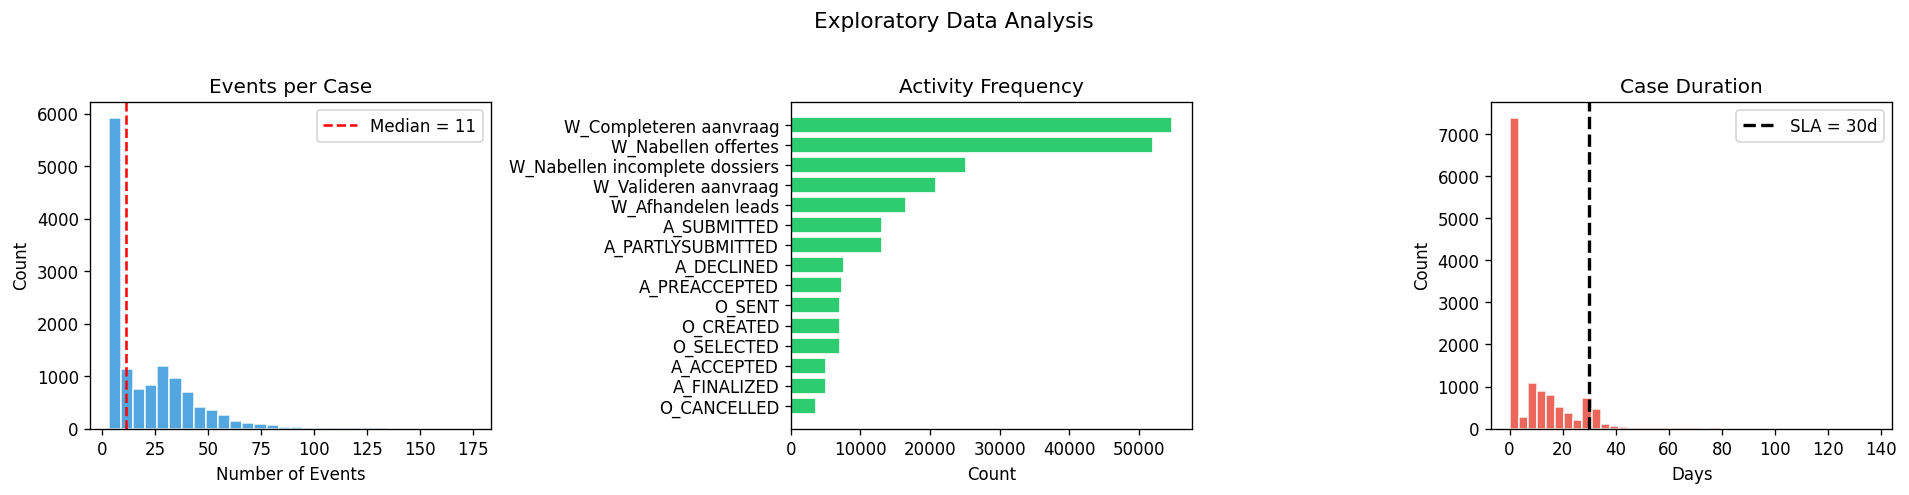

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

events_per_case = df.groupby("case_id").size()
axes[0].hist(events_per_case, bins=30, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axvline(events_per_case.median(), color="red", ls="--",
                label=f"Median = {events_per_case.median():.0f}")
axes[0].set(title="Events per Case", xlabel="Number of Events", ylabel="Count")
axes[0].legend()

act_freq = df["activity"].value_counts()
axes[1].barh(act_freq.index[:15], act_freq.values[:15], color="#2ecc71", edgecolor="white")
axes[1].set(title="Activity Frequency", xlabel="Count")
axes[1].invert_yaxis()

case_dur = df.groupby("case_id")["timestamp"].agg(["min", "max"])
case_dur["days"] = (case_dur["max"] - case_dur["min"]).dt.total_seconds() / 86400
axes[2].hist(case_dur["days"], bins=40, color="#e74c3c", edgecolor="white", alpha=0.85)
axes[2].axvline(CONFIG["sla_threshold_days"], color="black", ls="--", lw=2,
                label=f"SLA = {CONFIG['sla_threshold_days']}d")
axes[2].set(title="Case Duration", xlabel="Days", ylabel="Count")
axes[2].legend()

plt.suptitle("Exploratory Data Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

SLA Threshold : 30 days
Total cases   : 13,087
On-time  (0)  : 11,693  (89.3%)
Violated (1)  : 1,394  (10.7%)


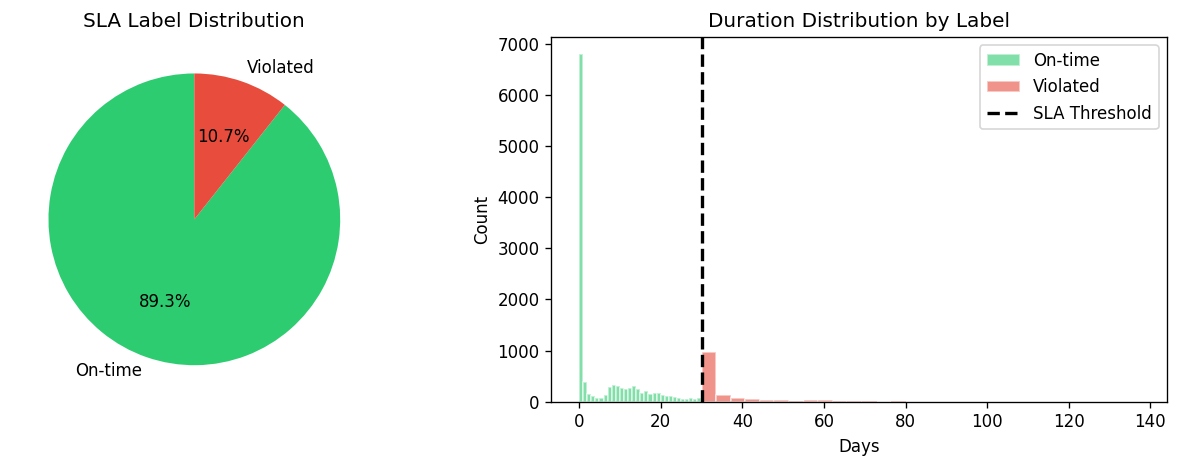

In [5]:
def generate_sla_labels(df: pd.DataFrame, threshold_days: int) -> pd.DataFrame:
    case_times = df.groupby("case_id")["timestamp"].agg(["min", "max"])
    case_times["duration"] = case_times["max"] - case_times["min"]
    case_times["duration_days"] = case_times["duration"].dt.total_seconds() / 86400
    case_times["label"] = (case_times["duration_days"] > threshold_days).astype(int)
    return case_times[["duration_days", "label"]].reset_index()

labels_df = generate_sla_labels(df, CONFIG["sla_threshold_days"])

n_total    = len(labels_df)
n_violated = int(labels_df["label"].sum())
n_ontime   = n_total - n_violated
viol_rate  = n_violated / n_total

print(f"SLA Threshold : {CONFIG['sla_threshold_days']} days")
print(f"Total cases   : {n_total:,}")
print(f"On-time  (0)  : {n_ontime:,}  ({1 - viol_rate:.1%})")
print(f"Violated (1)  : {n_violated:,}  ({viol_rate:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels_df["label"].value_counts().sort_index().plot.pie(
    labels=["On-time", "Violated"], autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"], ax=axes[0], startangle=90,
)
axes[0].set_ylabel("")
axes[0].set_title("SLA Label Distribution")

for lbl, color, name in [(0, "#2ecc71", "On-time"), (1, "#e74c3c", "Violated")]:
    subset = labels_df[labels_df["label"] == lbl]["duration_days"]
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor="white")
axes[1].axvline(CONFIG["sla_threshold_days"], color="black", ls="--", lw=2, label="SLA Threshold")
axes[1].set(title="Duration Distribution by Label", xlabel="Days", ylabel="Count")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Phase 2 — Process Mining & Graph Construction

⚠️  pm4py not installed — using DFG-only visualization


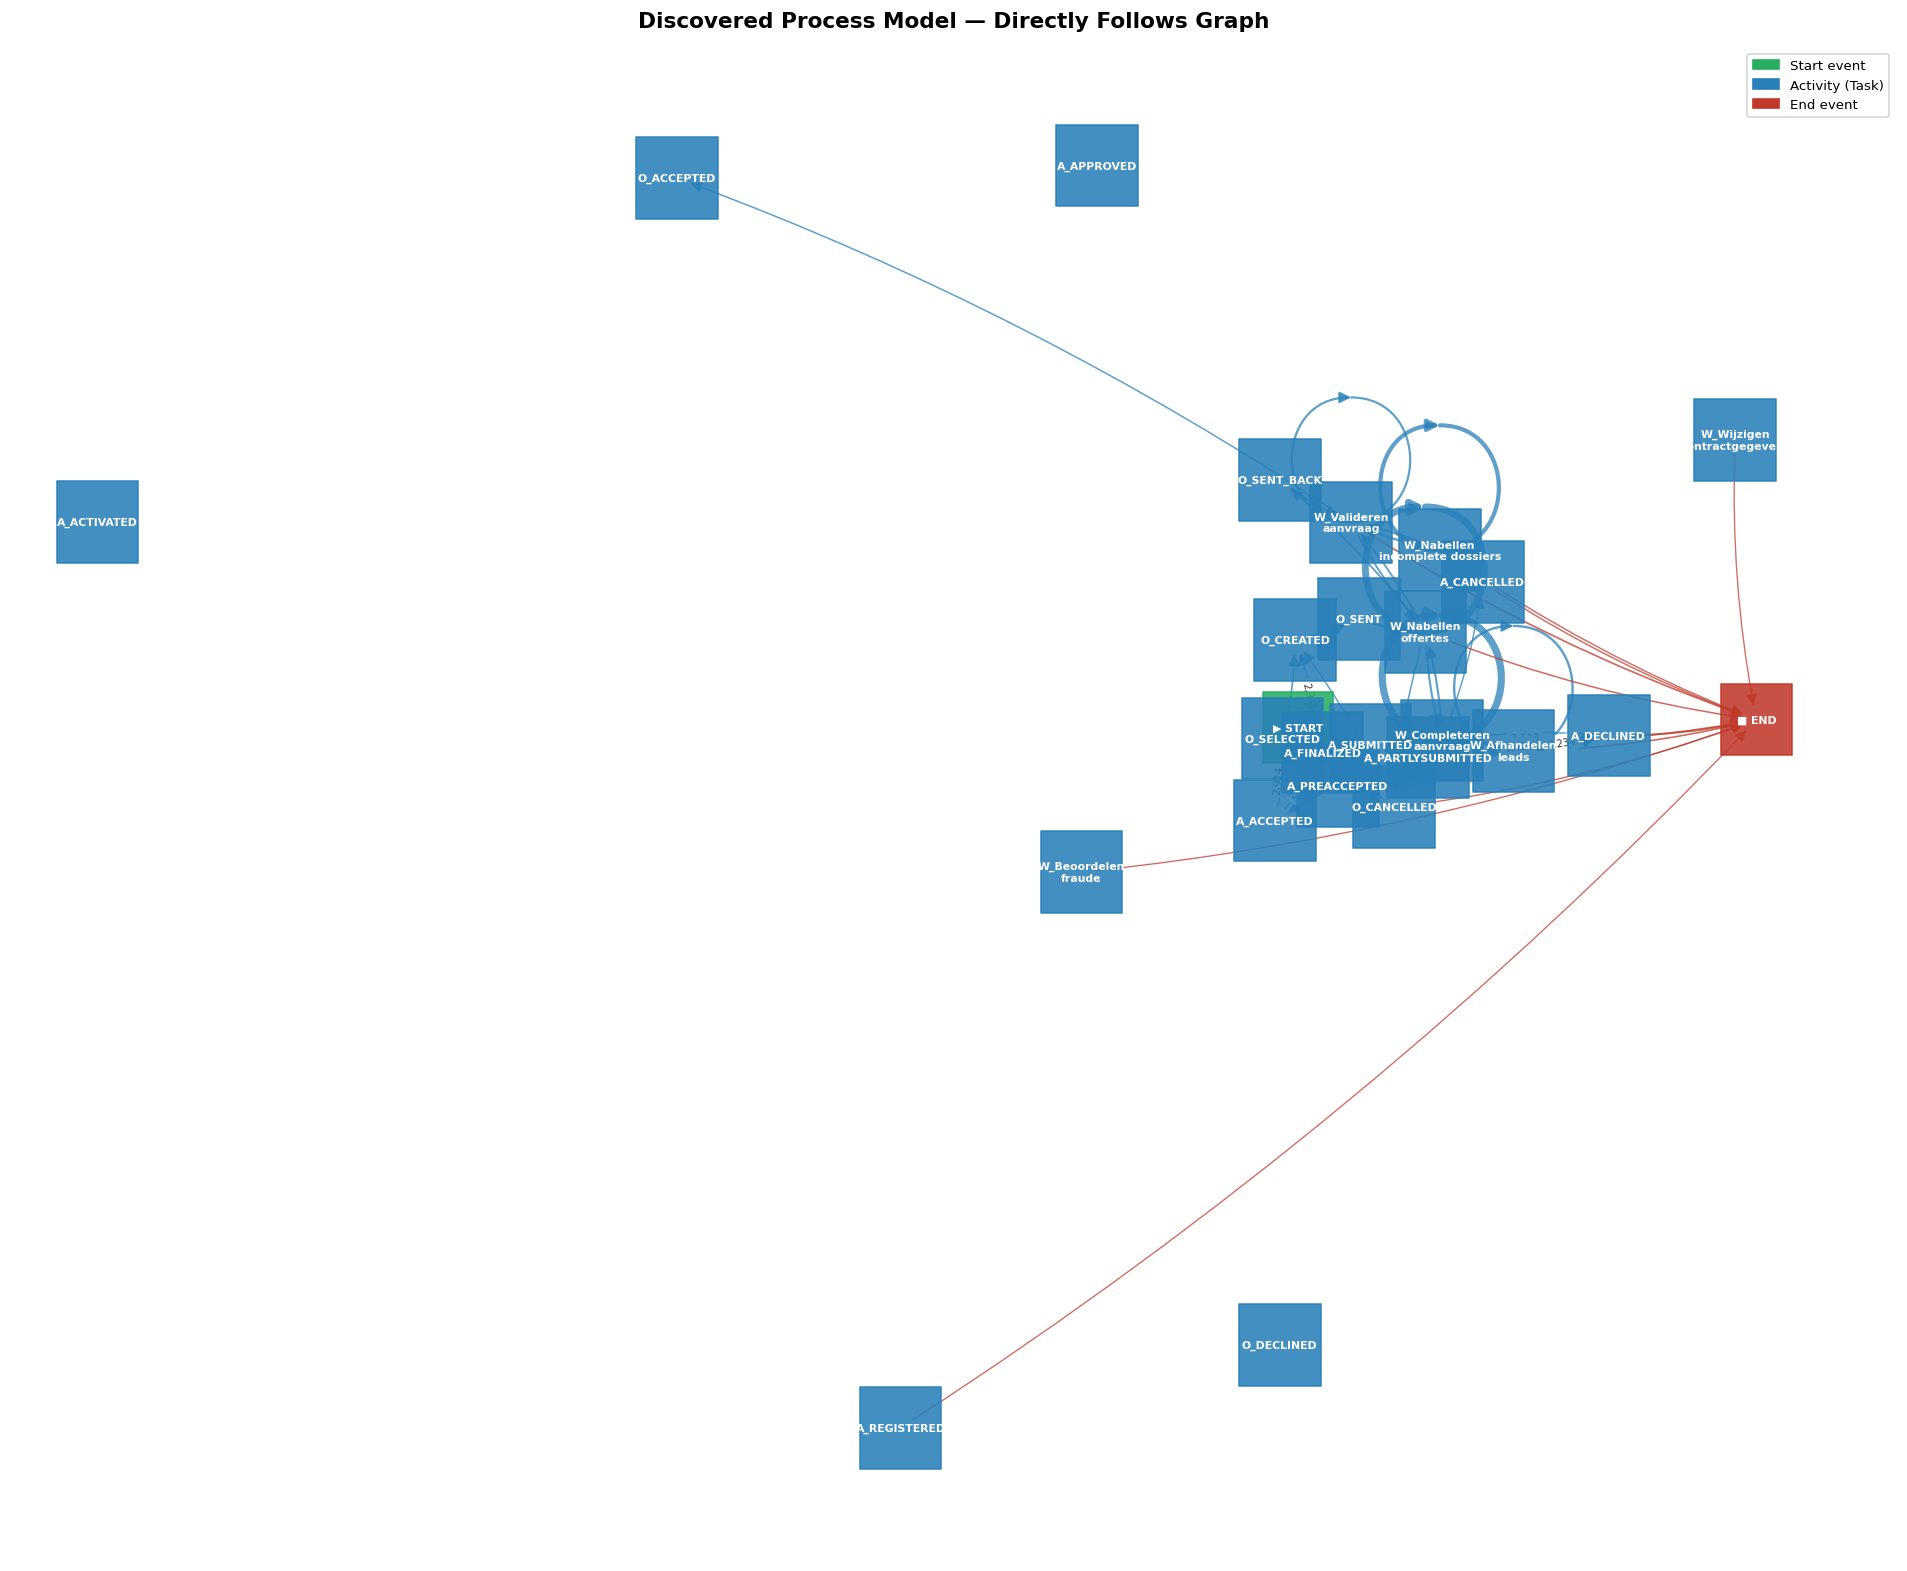

✅ Process model: 24 activities, 125 unique transitions
   Top 5 transitions: W_Completeren aanvraag→W_Completeren aanvraag(38004), W_Nabellen offertes→W_Nabellen offertes(36083), W_Nabellen incomplete dossiers→W_Nabellen incomplete dossiers(18475), A_SUBMITTED→A_PARTLYSUBMITTED(13087), A_PREACCEPTED→W_Completeren aanvraag(7367)


In [6]:
# ── Process Mining: Directly Follows Graph (BPMN-style, no Graphviz needed) ─
from collections import Counter

def _bpmn_layout(G):
    """Left-to-right hierarchical layout via longest-path layering."""
    try:
        order = list(nx.topological_sort(G))
    except nx.NetworkXUnfeasible:
        return nx.spring_layout(G, seed=42, k=2.5)

    # Assign layer = longest path from any source
    layer = {n: 0 for n in G.nodes()}
    for n in order:
        for succ in G.successors(n):
            layer[succ] = max(layer[succ], layer[n] + 1)

    # Group nodes by layer
    from collections import defaultdict
    buckets = defaultdict(list)
    for n, l in layer.items():
        buckets[l].append(n)

    pos = {}
    for l, nodes in buckets.items():
        for j, n in enumerate(sorted(nodes)):
            pos[n] = (l * 2.5, -j * 1.4)
    return pos


def draw_bpmn_dfg(df, top_n_edges=40,
                  title="Discovered Process Model — Directly Follows Graph"):
    """
    Render a BPMN-style Directly Follows Graph from an event log.
    Nodes  = activities (BPMN Task boxes)
    Edges  = directly-follows transitions, thickness ∝ frequency
    Start/End markers added automatically.
    """
    transitions = Counter()
    start_counts = Counter()
    end_counts   = Counter()

    for _, cdf in df.groupby("case_id"):
        acts = cdf.sort_values("timestamp")["activity"].tolist()
        if not acts:
            continue
        start_counts[acts[0]]  += 1
        end_counts[acts[-1]]   += 1
        for a, b in zip(acts, acts[1:]):
            transitions[(a, b)] += 1

    activities = sorted(df["activity"].unique())

    G = nx.DiGraph()
    G.add_nodes_from(["▶ START", "■ END"])
    G.add_nodes_from(activities)

    # Start → first activities
    for act, cnt in start_counts.items():
        G.add_edge("▶ START", act, weight=cnt)
    # Last activities → End
    for act, cnt in end_counts.items():
        G.add_edge(act, "■ END", weight=cnt)
    # Top N transitions (keep diagram readable)
    for (a, b), cnt in transitions.most_common(top_n_edges):
        G.add_edge(a, b, weight=cnt)

    pos = _bpmn_layout(G)

    max_w = max((d["weight"] for _, _, d in G.edges(data=True)), default=1)
    edge_widths = [0.8 + 3.5 * G[u][v]["weight"] / max_w for u, v in G.edges()]
    edge_colors = [
        "#27ae60" if u == "▶ START" else
        "#c0392b" if v == "■ END"   else
        "#2980b9"
        for u, v in G.edges()
    ]

    fig, ax = plt.subplots(figsize=(16, max(6, len(activities) * 0.55)))

    # Edges
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width=edge_widths, edge_color=edge_colors,
        arrows=True, arrowsize=14, alpha=0.75,
        connectionstyle="arc3,rad=0.06",
    )

    # Nodes: colour by type
    node_colors = []
    node_sizes  = []
    for n in G.nodes():
        if n == "▶ START":
            node_colors.append("#27ae60"); node_sizes.append(1800)
        elif n == "■ END":
            node_colors.append("#c0392b"); node_sizes.append(1800)
        else:
            node_colors.append("#2980b9"); node_sizes.append(2400)

    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes,
        node_shape="s", alpha=0.88,
    )

    # Labels
    short_labels = {
        n: n if n in ("▶ START", "■ END")
           else ("\n".join(n.split(" ", 1)) if " " in n else n)
        for n in G.nodes()
    }
    nx.draw_networkx_labels(G, pos, short_labels, ax=ax,
                            font_size=6.5, font_color="white", font_weight="bold")

    # Edge frequency labels (top 15 only)
    top_edges = {(a, b): f"{G[a][b]['weight']:,}"
                 for a, b in list(G.edges())[:15]
                 if a not in ("▶ START",) and b not in ("■ END",)}
    nx.draw_networkx_edge_labels(G, pos, top_edges, ax=ax,
                                 font_size=6, alpha=0.8)

    # Legend
    handles = [
        mpatches.Patch(color="#27ae60", label="Start event"),
        mpatches.Patch(color="#2980b9", label="Activity (Task)"),
        mpatches.Patch(color="#c0392b", label="End event"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\u2705 Process model: {len(activities)} activities, "
          f"{len(transitions)} unique transitions")
    print(f"   Top 5 transitions: "
          + ", ".join(f"{a}→{b}({c})" for (a,b),c in transitions.most_common(5)))
    return transitions


# ── Optional: pm4py richer discovery ────────────────────────────────────────
try:
    import pm4py

    pm4py_df = df.rename(columns={
        "case_id":   "case:concept:name",
        "activity":  "concept:name",
        "timestamp": "time:timestamp",
    })
    if "resource" in df.columns:
        pm4py_df = pm4py_df.rename(columns={"resource": "org:resource"})

    process_tree = pm4py.discover_process_tree_inductive(pm4py_df)
    bpmn_model   = pm4py.convert_to_bpmn(process_tree)
    print(f"\u2705 pm4py process tree discovered: {process_tree}")
    print("   (Graphviz rendering skipped — using DFG visualization below)")

except ImportError:
    print("\u26a0\ufe0f  pm4py not installed — using DFG-only visualization")
except Exception as e:
    print(f"\u26a0\ufe0f  pm4py discovery skipped: {e}")

# Always render the DFG (works without Graphviz or pm4py)
import matplotlib.patches as mpatches
transitions = draw_bpmn_dfg(df)


In [7]:
def build_activity_index(df: pd.DataFrame) -> dict:
    """Deterministic activity -> integer mapping (sorted for reproducibility)."""
    activities = sorted(df["activity"].unique())
    return {act: idx for idx, act in enumerate(activities)}


N_ACTIVITIES = df["activity"].nunique()

def case_to_graph(
    case_df: pd.DataFrame,
    activity_idx: dict,
    label: int,
    case_id: str,
    prefix_len: int = None,
    _sorted: bool = False,
) -> Data:
    """
    Convert one case (or a prefix of it) into a PyG Data object.

    If prefix_len is given, only the first prefix_len events are used.
    Set _sorted=True if case_df is already sorted by timestamp (avoids redundant sort).

    Nodes  = activity-event instances
    Edges  = directed 'directly follows' links
    Features (N_act + 2 dims): one-hot activity, time-since-start (days), time-since-prev (days)
    """
    if not _sorted:
        case_df = case_df.sort_values("timestamp").reset_index(drop=True)
    if prefix_len is not None:
        case_df = case_df.iloc[:prefix_len]

    n      = len(case_df)
    n_act  = len(activity_idx)

    acts = case_df["activity"].values
    ts   = case_df["timestamp"].values
    t0   = ts[0]

    features = np.zeros((n, n_act + 2), dtype=np.float32)
    for i in range(n):
        features[i, activity_idx.get(acts[i], 0)] = 1.0
        features[i, n_act]     = (ts[i] - t0) / np.timedelta64(1, "D")
        features[i, n_act + 1] = (ts[i] - ts[i - 1]) / np.timedelta64(1, "D") if i > 0 else 0.0

    x = torch.from_numpy(features)

    if n > 1:
        edge_index = torch.tensor(
            [list(range(n - 1)), list(range(1, n))], dtype=torch.long
        )
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)

    data = Data(
        x=x,
        edge_index=edge_index,
        y=torch.tensor([label], dtype=torch.float),
    )
    data.case_id    = case_id
    data.activities = case_df["activity"].tolist()
    data.prefix_len = prefix_len or n
    data.full_len   = n
    return data


activity_idx = build_activity_index(df)
IN_CHANNELS = N_ACTIVITIES + 2

print(f"Activity vocabulary ({len(activity_idx)} activities):")
for act, idx in activity_idx.items():
    print(f"  [{idx:2d}] {act}")
print(f"\nNode feature dim: {IN_CHANNELS}  ({N_ACTIVITIES} one-hot + 2 temporal)")

Activity vocabulary (24 activities):
  [ 0] A_ACCEPTED
  [ 1] A_ACTIVATED
  [ 2] A_APPROVED
  [ 3] A_CANCELLED
  [ 4] A_DECLINED
  [ 5] A_FINALIZED
  [ 6] A_PARTLYSUBMITTED
  [ 7] A_PREACCEPTED
  [ 8] A_REGISTERED
  [ 9] A_SUBMITTED
  [10] O_ACCEPTED
  [11] O_CANCELLED
  [12] O_CREATED
  [13] O_DECLINED
  [14] O_SELECTED
  [15] O_SENT
  [16] O_SENT_BACK
  [17] W_Afhandelen leads
  [18] W_Beoordelen fraude
  [19] W_Completeren aanvraag
  [20] W_Nabellen incomplete dossiers
  [21] W_Nabellen offertes
  [22] W_Valideren aanvraag
  [23] W_Wijzigen contractgegevens

Node feature dim: 26  (24 one-hot + 2 temporal)


Case-level split: train=9,160  val=1,309  test=2,618
   ... processed 3,000 / 13,087 cases
   ... processed 6,000 / 13,087 cases
   ... processed 9,000 / 13,087 cases
   ... processed 12,000 / 13,087 cases

✅ Built prefix graphs in 71.6s
   Prefix levels : ['20%', '40%', '60%', '80%', '100%']
   Node features : 26 dims  (24 one-hot + 2 temporal, z-normed)
   Temporal normalisation (from train): t_start μ=4.70 σ=8.46  t_prev μ=0.33 σ=1.38

Split   Graphs  Cases  On-time  Violated   Viol%
--------------------------------------------------
Train   45,800  9,160   40,950     4,850   10.6%
Val      6,545  1,309    5,820       725   11.1%
Test    13,090  2,618   11,695     1,395   10.7%

── Node Features ──────────────────────────────────────────────────────
Activity                               Total   Violated   SLA Rate
─────────────────────────────────────────────────────────────────
A_CANCELLED                            2,807      1,091     38.87%
W_Nabellen offertes                  

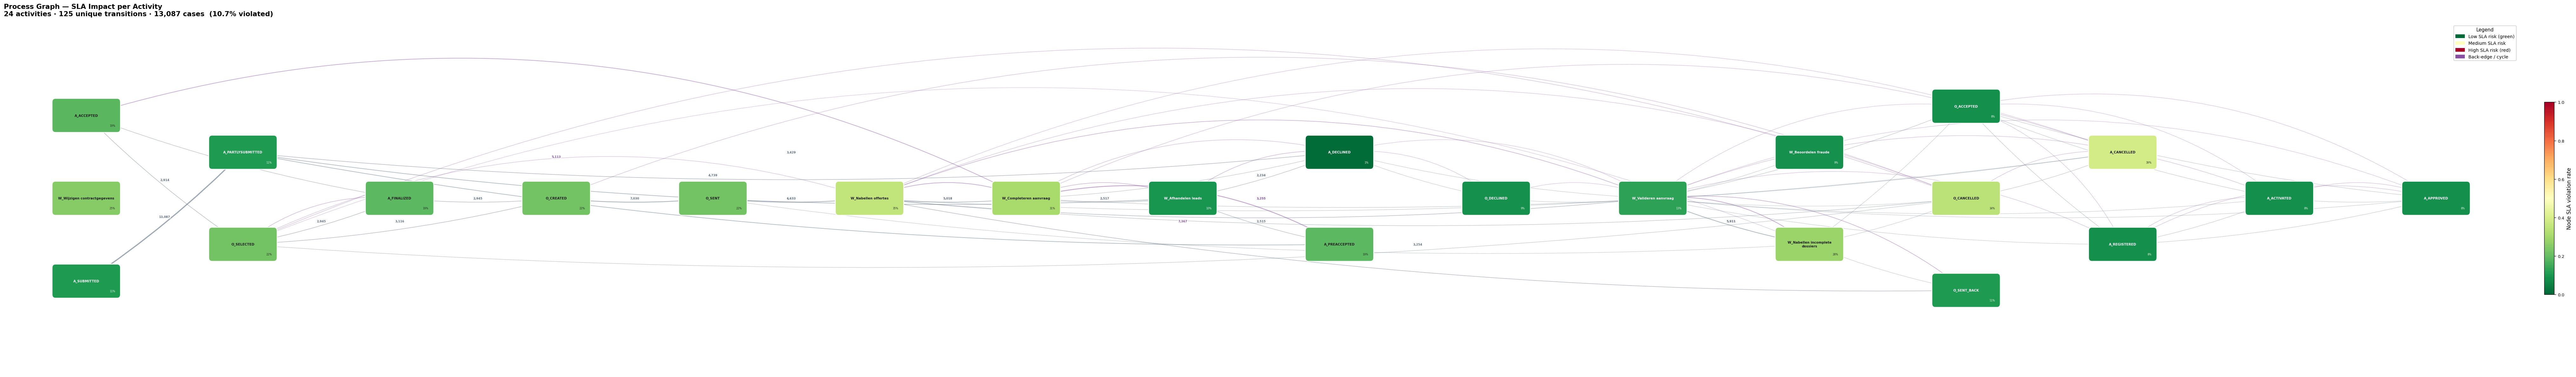


✅ Process SLA graph saved → report/process_sla_graph.png

── Graph Stats ────────────────────────────────────────────────────────
   Nodes / graph : min=3  avg=20.0  max=175
   Activities    : 24
   Transitions   : 125 unique  (249,113 total)
   Top-5 transitions:
     W_Completeren aanvraag  →  W_Completeren aanvraag  (38,004×)
     W_Nabellen offertes  →  W_Nabellen offertes  (36,083×)
     W_Nabellen incomplete dossiers  →  W_Nabellen incomplete dossiers  (18,475×)
     A_SUBMITTED  →  A_PARTLYSUBMITTED  (13,087×)
     A_PREACCEPTED  →  W_Completeren aanvraag  (7,367×)
   Highest SLA risk activities:
     A_CANCELLED                          SLA rate=38.9%  (appeared in 2,807 cases)
     W_Nabellen offertes                  SLA rate=35.5%  (appeared in 52,016 cases)
     O_CANCELLED                          SLA rate=34.0%  (appeared in 3,655 cases)
     W_Completeren aanvraag               SLA rate=30.7%  (appeared in 54,850 cases)
     W_Nabellen incomplete dossiers       SLA rate

In [8]:
seed_everything(CONFIG["seed"])

PREFIX_PCTS = [0.2, 0.4, 0.6, 0.8, 1.0]

# ── Step 1: case-level split (NO case appears in >1 split) ──
case_ids = labels_df["case_id"].values
case_labels = labels_df["label"].values

train_cids, test_cids = train_test_split(
    case_ids, test_size=CONFIG["test_size"],
    random_state=CONFIG["seed"], stratify=case_labels,
)
train_labels_tmp = labels_df[labels_df["case_id"].isin(train_cids)]["label"].values
train_cids, val_cids = train_test_split(
    train_cids,
    test_size=CONFIG["val_size"] / (1 - CONFIG["test_size"]),
    random_state=CONFIG["seed"], stratify=train_labels_tmp,
)

split_map = {}
for c in train_cids: split_map[c] = "train"
for c in val_cids:   split_map[c] = "val"
for c in test_cids:  split_map[c] = "test"

print(f"Case-level split: train={len(train_cids):,}  val={len(val_cids):,}  test={len(test_cids):,}")

# ── Step 2: build prefix graphs within each split ──
case_groups = {cid: cdf.sort_values("timestamp").reset_index(drop=True)
               for cid, cdf in df.groupby("case_id")}

train_data, val_data, test_data = [], [], []
full_graph_list = []
t_build = time.time()

for idx, (cid, cdf) in enumerate(case_groups.items()):
    row = labels_df.loc[labels_df["case_id"] == cid]
    if row.empty or cid not in split_map:
        continue
    label = int(row["label"].values[0])
    n_events = len(cdf)
    split = split_map[cid]

    full_g = case_to_graph(cdf, activity_idx, label, cid, _sorted=True)
    full_graph_list.append(full_g)

    bucket = train_data if split == "train" else (val_data if split == "val" else test_data)
    for pct in PREFIX_PCTS:
        plen = max(2, int(n_events * pct))
        if plen == n_events and pct < 1.0:
            continue
        g = case_to_graph(cdf, activity_idx, label, cid, prefix_len=plen, _sorted=True)
        bucket.append(g)

    if (idx + 1) % 3000 == 0:
        print(f"   ... processed {idx+1:,} / {len(case_groups):,} cases")

build_time = time.time() - t_build

# ── Step 3: normalise temporal features (z-score from train only) ──
train_t_start = [g.x[:, -2].numpy() for g in train_data]
train_t_prev  = [g.x[:, -1].numpy() for g in train_data]
t_start_all = np.concatenate(train_t_start)
t_prev_all  = np.concatenate(train_t_prev)

NORM_STATS = {
    "t_start_mean": float(t_start_all.mean()), "t_start_std": float(t_start_all.std() + 1e-8),
    "t_prev_mean":  float(t_prev_all.mean()),  "t_prev_std":  float(t_prev_all.std() + 1e-8),
}

def normalise_graphs(graphs):
    for g in graphs:
        g.x[:, -2] = (g.x[:, -2] - NORM_STATS["t_start_mean"]) / NORM_STATS["t_start_std"]
        g.x[:, -1] = (g.x[:, -1] - NORM_STATS["t_prev_mean"])  / NORM_STATS["t_prev_std"]

normalise_graphs(train_data)
normalise_graphs(val_data)
normalise_graphs(test_data)
normalise_graphs(full_graph_list)

print(f"\n\u2705 Built prefix graphs in {build_time:.1f}s")
print(f"   Prefix levels : {[f'{int(p*100)}%' for p in PREFIX_PCTS]}")
print(f"   Node features : {train_data[0].x.shape[1]} dims  ({N_ACTIVITIES} one-hot + 2 temporal, z-normed)")
print(f"   Temporal normalisation (from train): "
      f"t_start \u03bc={NORM_STATS['t_start_mean']:.2f} \u03c3={NORM_STATS['t_start_std']:.2f}  "
      f"t_prev \u03bc={NORM_STATS['t_prev_mean']:.2f} \u03c3={NORM_STATS['t_prev_std']:.2f}")

print(f"\n{'Split':<6} {'Graphs':>7} {'Cases':>6} {'On-time':>8} {'Violated':>9} {'Viol%':>7}")
print("-" * 50)
for name, split in [("Train", train_data), ("Val", val_data), ("Test", test_data)]:
    lbls = [int(g.y.item()) for g in split]
    cids = set(g.case_id for g in split)
    n1 = sum(lbls)
    print(f"{name:<6} {len(split):>7,} {len(cids):>6,} {len(split)-n1:>8,} {n1:>9,} {n1/len(split):>7.1%}")

n_nodes_list = [g.x.shape[0] for g in full_graph_list]

REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
#  Aggregated Process Graph  —  nodes=activities, edges=transitions
#  Node colour  = SLA violation rate  (white→red gradient)
#  Edge thickness = transition frequency
# ═══════════════════════════════════════════════════════════════════════════════

from collections import Counter
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── 1. Compute per-node and per-edge statistics ───────────────────────────────
act_total    = Counter()   # times activity appears in any case
act_violated = Counter()   # times activity appears in a violated case
transitions  = Counter()   # (src_activity, dst_activity) → count

for g in full_graph_list:
    label = int(g.y.item())
    acts  = g.activities
    for a in acts:
        act_total[a]    += 1
        if label == 1:
            act_violated[a] += 1
    for src, dst in zip(acts, acts[1:]):
        transitions[(src, dst)] += 1

activities = sorted(act_total.keys())

# SLA violation rate per activity (0 = never violated, 1 = always violated)
sla_rate = {a: act_violated[a] / act_total[a] if act_total[a] > 0 else 0
            for a in activities}

# ── 2. Print node feature table ───────────────────────────────────────────────
print("\n── Node Features ──────────────────────────────────────────────────────")
print(f"{'Activity':<35} {'Total':>8} {'Violated':>10} {'SLA Rate':>10}")
print("─" * 65)
for a in sorted(activities, key=lambda x: -sla_rate[x]):
    print(f"{a:<35} {act_total[a]:>8,} {act_violated[a]:>10,} {sla_rate[a]:>10.2%}")

# ── 3. Build directed graph ────────────────────────────────────────────────────
G = nx.DiGraph()
for a in activities:
    G.add_node(a, sla=sla_rate[a], count=act_total[a])

top_n_edges = 80
for (src, dst), cnt in transitions.most_common(top_n_edges):
    G.add_edge(src, dst, weight=cnt)

# ── 4. Layout ─────────────────────────────────────────────────────────────────
def _break_cycles(G):
    G2 = nx.DiGraph(G); G2.remove_edges_from(list(nx.selfloop_edges(G2)))
    back, visited, stack = set(), set(), set()
    def dfs(u):
        visited.add(u); stack.add(u)
        for v in list(G2.successors(u)):
            if (u, v) in back: continue
            if v not in visited: dfs(v)
            elif v in stack:    back.add((u, v))
        stack.discard(u)
    for n in list(G2.nodes()):
        if n not in visited: dfs(n)
    G2.remove_edges_from(back)
    return G2, back

def _layered_pos(G_dag, x_gap=3.8, y_gap=2.0):
    from collections import defaultdict
    try: order = list(nx.topological_sort(G_dag))
    except: return None
    layer = defaultdict(int)
    for n in order:
        for s in G_dag.successors(n):
            layer[s] = max(layer[s], layer[n] + 1)
    buckets = defaultdict(list)
    for n, l in layer.items(): buckets[l].append(n)
    pos = {}
    for l, nodes in buckets.items():
        ns = sorted(nodes)
        for j, n in enumerate(ns):
            pos[n] = (l * x_gap, -(j - (len(ns)-1)/2) * y_gap)
    return pos

def _push_apart(pos, min_d=1.7, iters=80):
    nodes = list(pos.keys())
    for _ in range(iters):
        moved = False
        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                a, b = nodes[i], nodes[j]
                dx = pos[b][0]-pos[a][0]; dy = pos[b][1]-pos[a][1]
                d  = (dx**2+dy**2)**0.5
                if d < min_d and d > 1e-6:
                    push = (min_d-d)/2; nx_ = dx/d*push; ny_ = dy/d*push
                    pos[a] = (pos[a][0]-nx_, pos[a][1]-ny_)
                    pos[b] = (pos[b][0]+nx_, pos[b][1]+ny_)
                    moved = True
        if not moved: break
    return pos

G_dag, back_edges = _break_cycles(G)
pos = _layered_pos(G_dag) or nx.kamada_kawai_layout(G_dag, scale=6)
for n in G.nodes():
    if n not in pos: pos[n] = (0.0, 0.0)
pos = _push_apart(pos, min_d=1.8)

# ── 5. Visual attributes ──────────────────────────────────────────────────────
cmap_node = plt.cm.RdYlGn_r        # green=safe, red=high SLA risk
max_w = max((d["weight"] for _,_,d in G.edges(data=True)), default=1)

node_colors  = [cmap_node(G.nodes[n]["sla"]) for n in G.nodes()]
node_sizes   = [800 + 1200 * G.nodes[n]["count"] / max(act_total.values())
                for n in G.nodes()]

xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
fig_w = max(20, (max(xs)-min(xs)+5) * 1.1)
fig_h = max(10, (max(ys)-min(ys)+4) * 1.1)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F4F6F7")
ax.grid(True, color="white", linewidth=0.8, alpha=0.5)

# ── 6. Draw edges ─────────────────────────────────────────────────────────────
for u, v, d in G.edges(data=True):
    w   = d["weight"]
    lw  = 0.6 + 4.5 * w / max_w
    al  = 0.40 + 0.55 * w / max_w
    rad = 0.20 if (u, v) in back_edges else 0.05
    ec  = "#884EA0" if (u, v) in back_edges else "#5D6D7E"
    ax.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", color=ec, lw=lw, alpha=al,
                                connectionstyle=f"arc3,rad={rad}",
                                mutation_scale=12),
                zorder=2)
    # frequency label on top-30 edges
    if w >= sorted([d2["weight"] for _,_,d2 in G.edges(data=True)],
                   reverse=True)[:30][-1]:
        mx, my = (pos[u][0]+pos[v][0])/2, (pos[u][1]+pos[v][1])/2
        ax.text(mx, my, f"{w:,}", ha="center", va="center",
                fontsize=5.5, color=ec, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                          edgecolor="none", alpha=0.80), zorder=3)

# ── 7. Draw nodes ─────────────────────────────────────────────────────────────
BW, BH = 1.50, 0.58
for i, n in enumerate(G.nodes()):
    x, y = pos[n]
    r, g_ch, b, _ = cmap_node(G.nodes[n]["sla"])
    # luminance — use white text on dark/red backgrounds
    lum = 0.299*r + 0.587*g_ch + 0.114*b
    txt_color = "white" if lum < 0.55 else "#1C1C1C"

    box = FancyBboxPatch((x-BW/2, y-BH/2), BW, BH,
                          boxstyle="round,pad=0.08",
                          facecolor=(r, g_ch, b), edgecolor="white",
                          linewidth=1.6, zorder=4)
    ax.add_patch(box)

    words = n.split()
    lbl = (" ".join(words[:2])+"\n"+" ".join(words[2:])) if len(words) > 2 else n
    ax.text(x, y, lbl, ha="center", va="center",
            fontsize=6.2, color=txt_color, fontweight="bold",
            linespacing=1.25, zorder=5, clip_on=False)

    # SLA rate badge (bottom-right of node)
    ax.text(x+BW/2-0.05, y-BH/2+0.04,
            f"{G.nodes[n]['sla']:.0%}",
            ha="right", va="bottom", fontsize=4.8,
            color=txt_color, alpha=0.9, zorder=6)

# ── 8. Axes & legend ──────────────────────────────────────────────────────────
ax.set_xlim(min(xs)-2.0, max(xs)+2.0)
ax.set_ylim(min(ys)-1.8, max(ys)+1.8)
ax.axis("off")

# Colour-bar for SLA rate
sm = plt.cm.ScalarMappable(cmap=cmap_node, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.018, pad=0.01,
                     shrink=0.55, label="Node SLA violation rate")
cbar.ax.tick_params(labelsize=8)

legend_h = [
    mpatches.Patch(color=cmap_node(0.0), label="Low SLA risk (green)"),
    mpatches.Patch(color=cmap_node(0.5), label="Medium SLA risk"),
    mpatches.Patch(color=cmap_node(1.0), label="High SLA risk (red)"),
    mpatches.Patch(color="#884EA0",       label="Back-edge / cycle"),
]
ax.legend(handles=legend_h, loc="upper right", fontsize=8.5,
          framealpha=0.92, edgecolor="#ccc", title="Legend", title_fontsize=9)

total_cases = len(full_graph_list)
violated    = sum(1 for g in full_graph_list if int(g.y.item()) == 1)
ax.set_title(
    f"Process Graph — SLA Impact per Activity\n"
    f"{len(activities)} activities · {len(transitions)} unique transitions · "
    f"{total_cases:,} cases  ({violated/total_cases:.1%} violated)",
    fontsize=13, fontweight="bold", pad=14, loc="left"
)

plt.tight_layout()
save_path = os.path.join(REPORT_DIR, "process_sla_graph.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\n✅ Process SLA graph saved → {save_path}")

# ── 9. Summary stats ──────────────────────────────────────────────────────────
print(f"\n── Graph Stats ────────────────────────────────────────────────────────")
print(f"   Nodes / graph : min={min(n_nodes_list)}  "
      f"avg={np.mean(n_nodes_list):.1f}  max={max(n_nodes_list)}")
print(f"   Activities    : {len(activities)}")
print(f"   Transitions   : {len(transitions)} unique  "
      f"({sum(transitions.values()):,} total)")
print(f"   Top-5 transitions:")
for (src, dst), cnt in transitions.most_common(5):
    print(f"     {src}  →  {dst}  ({cnt:,}×)")
print(f"   Highest SLA risk activities:")
for a in sorted(activities, key=lambda x: -sla_rate[x])[:5]:
    print(f"     {a:<35}  SLA rate={sla_rate[a]:.1%}  "
          f"(appeared in {act_total[a]:,} cases)")


---
## Phase 2b — GNN Model & Training

In [9]:
# Round 2 hyperparameter updates
CONFIG["hidden_dim"]  = 128
CONFIG["lr"]          = 5e-4
CONFIG["patience"]    = 20
CONFIG["batch_size"]  = 128

def _worker_init(wid):
    np.random.seed(CONFIG["seed"] + wid)

g_seed = torch.Generator().manual_seed(CONFIG["seed"])

train_loader = DataLoader(train_data, batch_size=CONFIG["batch_size"],
                          shuffle=True, worker_init_fn=_worker_init, generator=g_seed)
val_loader   = DataLoader(val_data,   batch_size=CONFIG["batch_size"])
test_loader  = DataLoader(test_data,  batch_size=CONFIG["batch_size"])

print(f"DataLoaders ready  (batch_size={CONFIG['batch_size']})")
print(f"Updated CONFIG: hidden_dim={CONFIG['hidden_dim']}, lr={CONFIG['lr']}, patience={CONFIG['patience']}")

DataLoaders ready  (batch_size=128)
Updated CONFIG: hidden_dim=128, lr=0.0005, patience=20


In [10]:
class SLA_GCN(torch.nn.Module):
    """2-layer GCN with global mean pooling for graph-level binary classification."""

    def __init__(self, in_channels: int, hidden: int = 64, dropout: float = 0.3):
        super().__init__()
        self.conv1   = GCNConv(in_channels, hidden)
        self.conv2   = GCNConv(hidden, hidden // 2)
        self.lin     = torch.nn.Linear(hidden // 2, 1)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)

    def get_graph_embedding(self, x, edge_index, batch):
        """Return graph-level embedding *before* the classification head."""
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        return global_mean_pool(x, batch)


seed_everything(CONFIG["seed"])
model = SLA_GCN(
    in_channels=IN_CHANNELS,
    hidden=CONFIG["hidden_dim"],
    dropout=CONFIG["dropout"],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

SLA_GCN(
  (conv1): GCNConv(26, 128)
  (conv2): GCNConv(128, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Trainable parameters: 11,777


In [11]:
seed_everything(CONFIG["seed"])

train_labels = torch.tensor([int(g.y.item()) for g in train_data])
raw_weight = (train_labels == 0).sum().float() / max((train_labels == 1).sum().float(), 1.0)
pos_weight = torch.tensor([raw_weight.sqrt()]).to(DEVICE)
print(f"Class balance  —  raw neg/pos = {raw_weight.item():.2f}  →  pos_weight = sqrt = {pos_weight.item():.2f}")

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"],
                             weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5,
)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(logits, batch.y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            all_preds.extend((torch.sigmoid(logits) >= 0.5).long().cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy().astype(int))

    return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, zero_division=0)


# ---- Training loop ----
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1, best_epoch, patience_ctr = 0.0, 0, 0
t0 = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_f1 = run_epoch(train_loader, train=True)
    vl_loss, vl_f1 = run_epoch(val_loader,   train=False)
    scheduler.step(vl_f1)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(vl_f1)

    tag = ""
    if vl_f1 > best_val_f1:
        best_val_f1, best_epoch, patience_ctr = vl_f1, epoch, 0
        torch.save(model.state_dict(), "best_model.pt")
        tag = " \u2605"
    else:
        patience_ctr += 1

    if epoch <= 5 or epoch % 10 == 0 or tag:
        lr = optimizer.param_groups[0]["lr"]
        print(f"Ep {epoch:3d}/{CONFIG['epochs']}  "
              f"TrLoss={tr_loss:.4f}  TrF1={tr_f1:.3f}  "
              f"VlLoss={vl_loss:.4f}  VlF1={vl_f1:.3f}  "
              f"LR={lr:.1e}{tag}")

    if patience_ctr >= CONFIG["patience"]:
        print(f"\n\u23f9 Early stopping at epoch {epoch}")
        break

elapsed = time.time() - t0
print(f"\n\u2705 Training done in {elapsed:.1f}s  |  Best val F1 = {best_val_f1:.4f} @ epoch {best_epoch}")

model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE, weights_only=True))
model.eval()
print("   Best checkpoint loaded.")

Class balance  —  raw neg/pos = 8.44  →  pos_weight = sqrt = 2.91
Ep   1/100  TrLoss=0.5081  TrF1=0.437  VlLoss=0.4316  VlF1=0.536  LR=5.0e-04 ★
Ep   2/100  TrLoss=0.3988  TrF1=0.565  VlLoss=0.4124  VlF1=0.550  LR=5.0e-04 ★
Ep   3/100  TrLoss=0.3842  TrF1=0.575  VlLoss=0.3948  VlF1=0.555  LR=5.0e-04 ★
Ep   4/100  TrLoss=0.3754  TrF1=0.579  VlLoss=0.3949  VlF1=0.553  LR=5.0e-04
Ep   5/100  TrLoss=0.3706  TrF1=0.585  VlLoss=0.3878  VlF1=0.567  LR=5.0e-04 ★
Ep   7/100  TrLoss=0.3649  TrF1=0.586  VlLoss=0.3826  VlF1=0.577  LR=5.0e-04 ★
Ep  10/100  TrLoss=0.3594  TrF1=0.590  VlLoss=0.3773  VlF1=0.578  LR=5.0e-04 ★
Ep  13/100  TrLoss=0.3553  TrF1=0.597  VlLoss=0.3787  VlF1=0.579  LR=5.0e-04 ★
Ep  16/100  TrLoss=0.3528  TrF1=0.601  VlLoss=0.3723  VlF1=0.580  LR=5.0e-04 ★
Ep  18/100  TrLoss=0.3530  TrF1=0.599  VlLoss=0.3697  VlF1=0.582  LR=5.0e-04 ★
Ep  19/100  TrLoss=0.3518  TrF1=0.602  VlLoss=0.3727  VlF1=0.587  LR=5.0e-04 ★
Ep  20/100  TrLoss=0.3510  TrF1=0.603  VlLoss=0.3680  VlF1=0.585  L

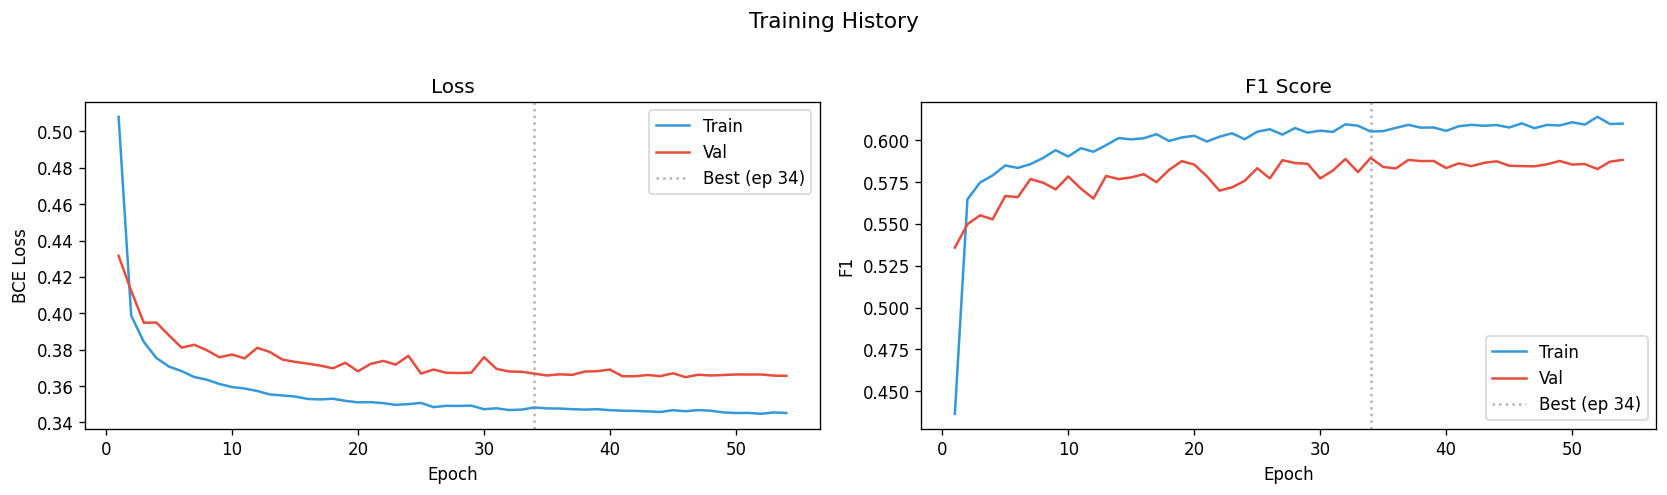

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ep_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep_range, history["train_loss"], label="Train", color="#3498db")
axes[0].plot(ep_range, history["val_loss"],   label="Val",   color="#e74c3c")
axes[0].axvline(best_epoch, color="gray", ls=":", alpha=0.6, label=f"Best (ep {best_epoch})")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="BCE Loss")
axes[0].legend()

axes[1].plot(ep_range, history["train_f1"], label="Train", color="#3498db")
axes[1].plot(ep_range, history["val_f1"],   label="Val",   color="#e74c3c")
axes[1].axvline(best_epoch, color="gray", ls=":", alpha=0.6, label=f"Best (ep {best_epoch})")
axes[1].set(title="F1 Score", xlabel="Epoch", ylabel="F1")
axes[1].legend()

plt.suptitle("Training History", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Phase 3 — Evaluation on Test Set

In [13]:
# ── Main evaluation on 100% completion test cases ──
test_case_ids = set(c for c in test_cids)
test_full = [g for g in full_graph_list if g.case_id in test_case_ids]

model.eval()
full_probs, full_labels = [], []
with torch.no_grad():
    for g in test_full:
        g_dev = g.to(DEVICE)
        bvec = torch.zeros(g_dev.num_nodes, dtype=torch.long, device=DEVICE)
        logit = model(g_dev.x, g_dev.edge_index, bvec)
        full_probs.append(torch.sigmoid(logit).item())
        full_labels.append(int(g.y.item()))

y_true = np.array(full_labels)
y_prob = np.array(full_probs)
y_pred = (y_prob >= 0.5).astype(int)
has_both = len(set(y_true)) > 1

metrics = {
    "Accuracy":  accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall":    recall_score(y_true, y_pred, zero_division=0),
    "F1-Score":  f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_true, y_prob)            if has_both else 0.0,
    "PR-AUC":    average_precision_score(y_true, y_prob)   if has_both else 0.0,
}

print("=" * 56)
print("  TEST SET EVALUATION (100% completion — complete cases)")
print("=" * 56)
for name, val in metrics.items():
    bar = "\u2588" * int(val * 30)
    print(f"  {name:<12}: {val:.4f}  {bar}")
print("=" * 56)
print()
print(classification_report(y_true, y_pred, target_names=["On-time", "Violated"]))

# ── Prefix-stratified evaluation (early-warning breakdown) ──
def _predict_prefix_normalised(case_df, pct):
    """Build a prefix graph, apply train-set normalisation, predict."""
    n_total = len(case_df)
    n_prefix = max(2, int(n_total * pct))
    pg = case_to_graph(case_df, activity_idx, 0, "_eval", prefix_len=n_prefix, _sorted=True)
    pg.x[:, -2] = (pg.x[:, -2] - NORM_STATS["t_start_mean"]) / NORM_STATS["t_start_std"]
    pg.x[:, -1] = (pg.x[:, -1] - NORM_STATS["t_prev_mean"])  / NORM_STATS["t_prev_std"]
    pg = pg.to(DEVICE)
    with torch.no_grad():
        bvec = torch.zeros(pg.num_nodes, dtype=torch.long, device=DEVICE)
        return torch.sigmoid(model(pg.x, pg.edge_index, bvec)).item()

print("\n" + "=" * 64)
print("  PREFIX-STRATIFIED EVALUATION (honest early-warning metrics)")
print("=" * 64)

pct_levels = [0.2, 0.4, 0.6, 0.8, 1.0]
pct_rows = []

for pct in pct_levels:
    pct_probs, pct_labels = [], []
    for g in test_full:
        cdf = case_groups[g.case_id]
        prob = _predict_prefix_normalised(cdf, pct)
        pct_probs.append(prob)
        pct_labels.append(int(g.y.item()))

    yt = np.array(pct_labels)
    yp = np.array(pct_probs)
    ypred = (yp >= 0.5).astype(int)
    hb = len(set(yt)) > 1

    pct_rows.append({
        "Completion": f"{int(pct*100)}%",
        "F1": f1_score(yt, ypred, zero_division=0),
        "Precision": precision_score(yt, ypred, zero_division=0),
        "Recall": recall_score(yt, ypred, zero_division=0),
        "ROC-AUC": roc_auc_score(yt, yp) if hb else 0.0,
    })

pct_df = pd.DataFrame(pct_rows)
print(pct_df.to_string(index=False))
print("=" * 64)

  TEST SET EVALUATION (100% completion — complete cases)
  Accuracy    : 0.9652  ████████████████████████████
  Precision   : 0.7568  ██████████████████████
  Recall      : 0.9928  █████████████████████████████
  F1-Score    : 0.8589  █████████████████████████
  ROC-AUC     : 0.9956  █████████████████████████████
  PR-AUC      : 0.9571  ████████████████████████████

              precision    recall  f1-score   support

     On-time       1.00      0.96      0.98      2339
    Violated       0.76      0.99      0.86       279

    accuracy                           0.97      2618
   macro avg       0.88      0.98      0.92      2618
weighted avg       0.97      0.97      0.97      2618


  PREFIX-STRATIFIED EVALUATION (honest early-warning metrics)
Completion       F1  Precision   Recall  ROC-AUC
       20% 0.095541   0.428571 0.053763 0.825943
       40% 0.416309   0.518717 0.347670 0.866150
       60% 0.599681   0.540230 0.673835 0.926329
       80% 0.660574   0.519507 0.906810 0.968

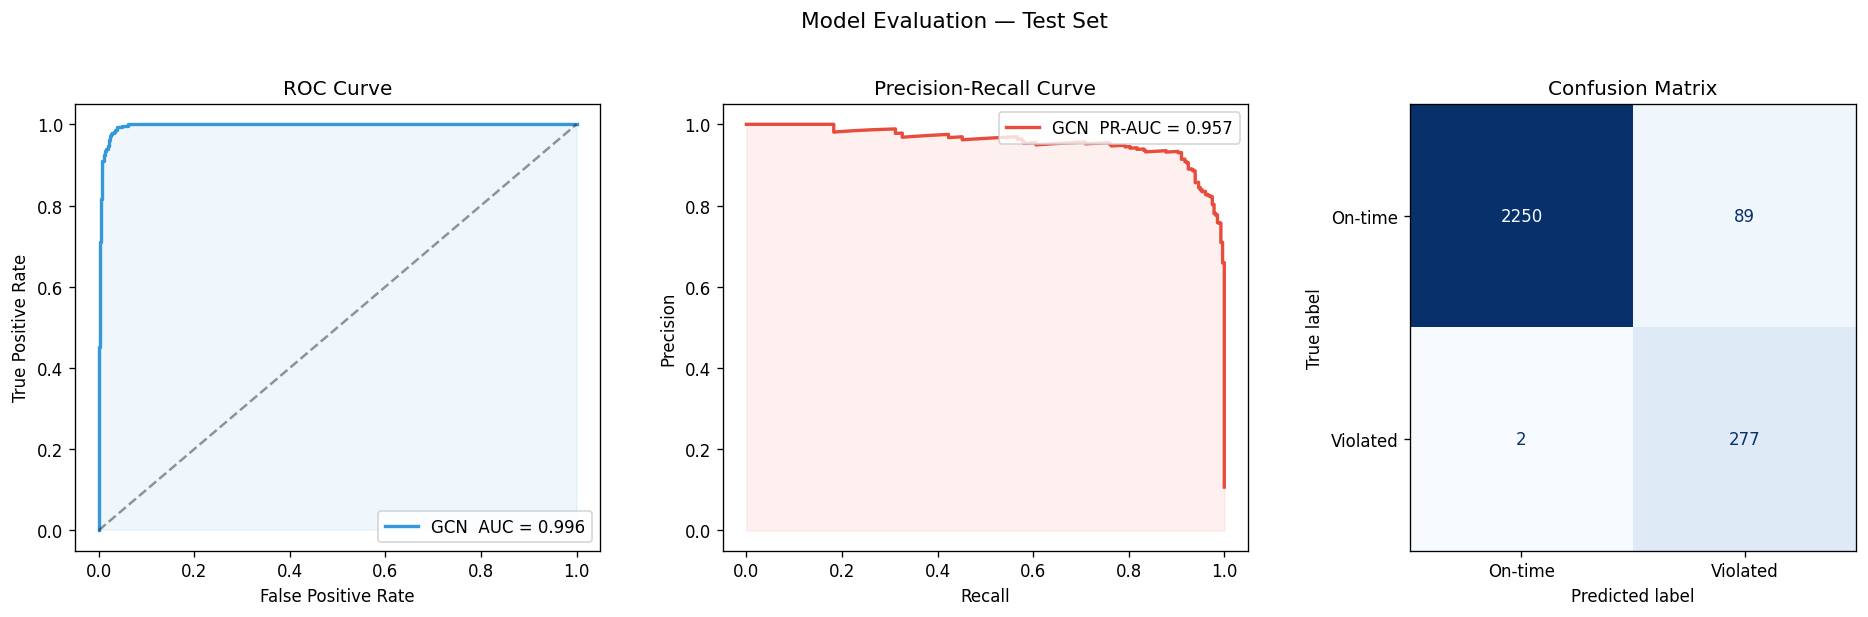

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

if has_both:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, color="#3498db", lw=2,
                label=f"GCN  AUC = {metrics['ROC-AUC']:.3f}")
    axes[0].fill_between(fpr, tpr, alpha=0.08, color="#3498db")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[0].legend(loc="lower right")

if has_both:
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    axes[1].plot(rec, prec, color="#e74c3c", lw=2,
                label=f"GCN  PR-AUC = {metrics['PR-AUC']:.3f}")
    axes[1].fill_between(rec, prec, alpha=0.08, color="#e74c3c")
axes[1].set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
axes[1].legend(loc="upper right")

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, ax=axes[2],
    display_labels=["On-time", "Violated"], cmap="Blues", colorbar=False,
)
axes[2].set_title("Confusion Matrix")

plt.suptitle("Model Evaluation \u2014 Test Set", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Graph Embedding Visualization (t-SNE)

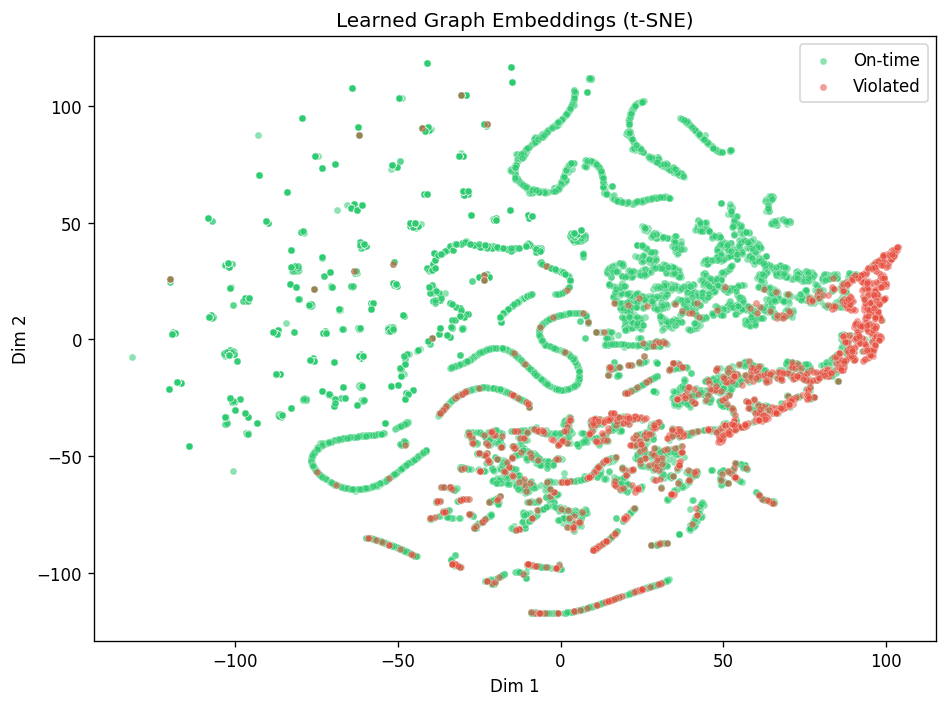

Embedding dim : 64
Graphs shown  : 13,090


In [15]:
seed_everything(CONFIG["seed"])

model.eval()
emb_list, emb_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        emb = model.get_graph_embedding(batch.x, batch.edge_index, batch.batch)
        emb_list.append(emb.cpu().numpy())
        emb_labels.extend(batch.y.cpu().numpy().astype(int))

embeddings = np.concatenate(emb_list, axis=0)
emb_labels = np.array(emb_labels)

tsne = TSNE(n_components=2, random_state=CONFIG["seed"], perplexity=30, max_iter=1000)
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, name, color in [(0, "On-time", "#2ecc71"), (1, "Violated", "#e74c3c")]:
    mask = emb_labels == lbl
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=color, label=name,
              alpha=0.55, s=18, edgecolors="white", linewidths=0.3)

ax.set(title="Learned Graph Embeddings (t-SNE)", xlabel="Dim 1", ylabel="Dim 2")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Embedding dim : {embeddings.shape[1]}")
print(f"Graphs shown  : {len(embeddings):,}")

---
## Phase 4 — Business Use Cases

### Use Case 1 — Early Warning on In-Progress Cases

Feed progressively longer prefixes of a case and watch the risk score evolve.  
A good model raises the alarm *before* the case completes.

Case 173694 (VIOLATED, 59 events):
  Risk @ 25%: 0.430
  Risk @ 50%: 0.572
  Risk @ 75%: 0.960
  Risk @100%: 0.983

Case 173928 (VIOLATED, 115 events):
  Risk @ 25%: 0.469
  Risk @ 50%: 0.992
  Risk @ 75%: 1.000
  Risk @100%: 1.000

Case 173724 (ON-TIME, 20 events):
  Risk @ 25%: 0.071
  Risk @ 50%: 0.316
  Risk @ 75%: 0.415
  Risk @100%: 0.055



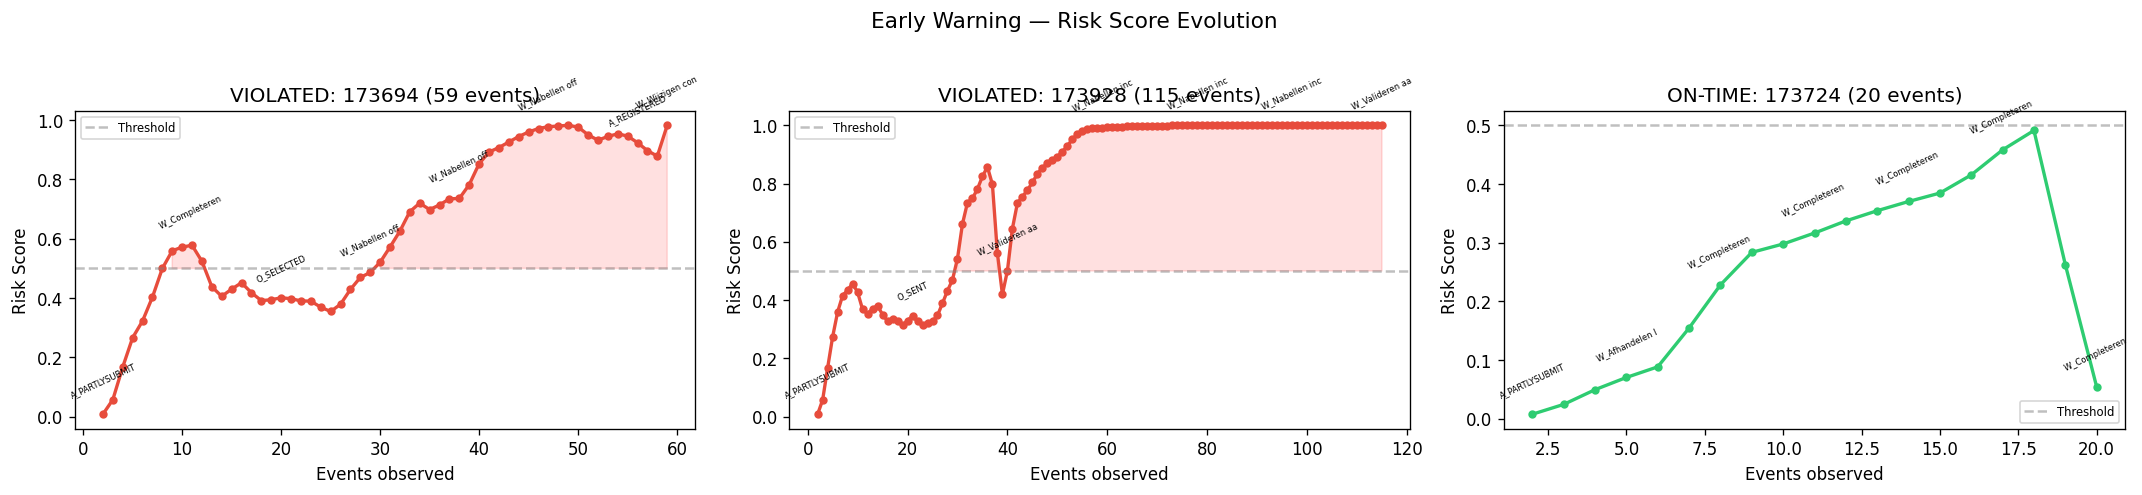

In [16]:
def predict_prefix(case_df, model, activity_idx, n_events):
    """Predict SLA risk using only the first n_events of a case (with normalisation)."""
    g = case_to_graph(case_df, activity_idx, label=0, case_id="_prefix", prefix_len=n_events, _sorted=True)
    g.x[:, -2] = (g.x[:, -2] - NORM_STATS["t_start_mean"]) / NORM_STATS["t_start_std"]
    g.x[:, -1] = (g.x[:, -1] - NORM_STATS["t_prev_mean"])  / NORM_STATS["t_prev_std"]
    g = g.to(DEVICE)
    model.eval()
    with torch.no_grad():
        batch_vec = torch.zeros(g.num_nodes, dtype=torch.long, device=DEVICE)
        logit = model(g.x, g.edge_index, batch_vec)
        return torch.sigmoid(logit).item()


# Pick 2 violated and 1 on-time case from the TEST set
test_violated = [g.case_id for g in test_full if int(g.y.item()) == 1]
test_ontime   = [g.case_id for g in test_full if int(g.y.item()) == 0]
violated_ids  = test_violated[:2]
ontime_ids    = test_ontime[:1]
demo_cases   = [(cid, 1) for cid in violated_ids] + [(cid, 0) for cid in ontime_ids]

fig, axes = plt.subplots(1, len(demo_cases), figsize=(6 * len(demo_cases), 4), squeeze=False)

for col, (sample_cid, true_label) in enumerate(demo_cases):
    sample_cdf = case_groups[sample_cid]
    n_ev = len(sample_cdf)

    prefixes    = list(range(2, n_ev + 1))
    risk_scores = [predict_prefix(sample_cdf, model, activity_idx, n) for n in prefixes]

    ax = axes[0][col]
    color = "#e74c3c" if true_label == 1 else "#2ecc71"
    label_str = "VIOLATED" if true_label == 1 else "ON-TIME"

    ax.plot(prefixes, risk_scores, "o-", color=color, lw=2, markersize=4)
    ax.axhline(0.5, color="gray", ls="--", alpha=0.5, label="Threshold")
    ax.fill_between(prefixes, risk_scores, 0.5,
                    where=[r >= 0.5 for r in risk_scores],
                    alpha=0.12, color="red")

    step = max(1, len(prefixes) // 6)
    for i, (n, s) in enumerate(zip(prefixes, risk_scores)):
        if i % step == 0 or n == n_ev:
            act = sample_cdf["activity"].iloc[n - 1]
            ax.annotate(act[:14], (n, s), textcoords="offset points",
                        xytext=(0, 10), fontsize=5, ha="center", rotation=25)

    ax.set(title=f"{label_str}: {sample_cid} ({n_ev} events)",
           xlabel="Events observed", ylabel="Risk Score")
    ax.legend(fontsize=7)

    mid = len(risk_scores) // 2
    print(f"Case {sample_cid} ({label_str}, {n_ev} events):")
    print(f"  Risk @ 25%: {risk_scores[max(0, len(risk_scores)//4 - 1)]:.3f}")
    print(f"  Risk @ 50%: {risk_scores[mid]:.3f}")
    print(f"  Risk @ 75%: {risk_scores[int(len(risk_scores)*0.75)]:.3f}")
    print(f"  Risk @100%: {risk_scores[-1]:.3f}\n")

plt.suptitle("Early Warning \u2014 Risk Score Evolution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Use Case 2 — Bottleneck Detection

Identify which activities contribute most to SLA violations by measuring  
learned node-embedding magnitude in violated cases.

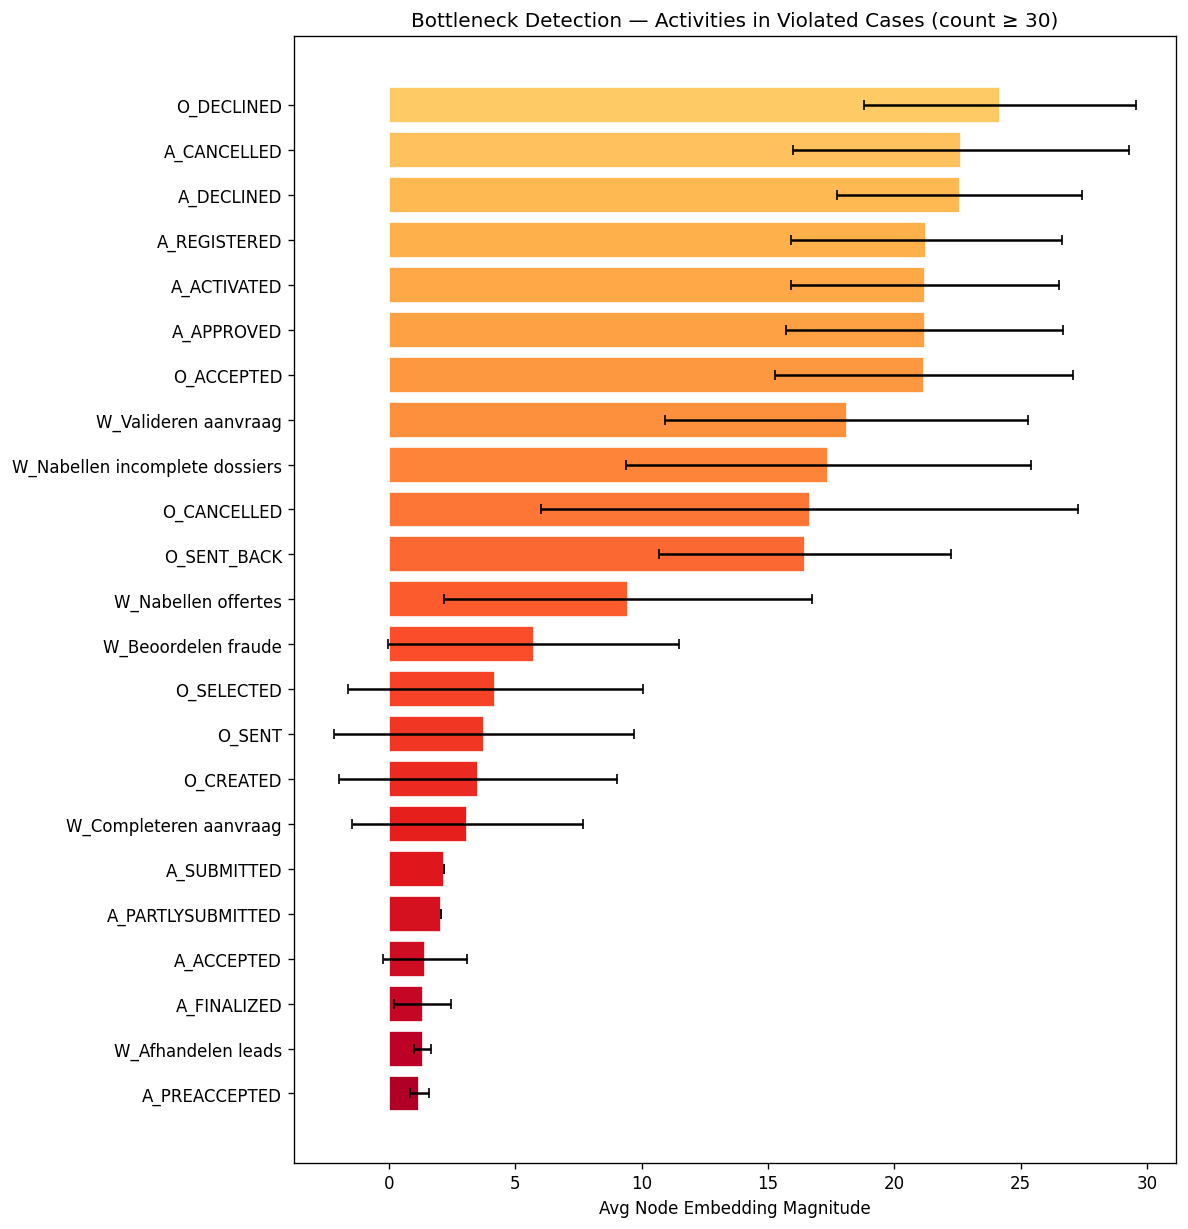


Bottleneck ranking (filtered: count >= 30, removed 1 rare activities):
                      Activity  Avg Importance          Std  Count
                    O_DECLINED       24.176483 5.389589e+00     71
                   A_CANCELLED       22.642498 6.646005e+00   1091
                    A_DECLINED       22.594721 4.855091e+00     74
                  A_REGISTERED       21.272739 5.364472e+00    190
                   A_ACTIVATED       21.210966 5.307971e+00    190
                    A_APPROVED       21.209518 5.479986e+00    190
                    O_ACCEPTED       21.187487 5.902951e+00    189
          W_Valideren aanvraag       18.124544 7.183192e+00   2678
W_Nabellen incomplete dossiers       17.392706 8.022340e+00   7138
                   O_CANCELLED       16.654463 1.063174e+01   1243
                   O_SENT_BACK       16.459454 5.779022e+00    369
           W_Nabellen offertes        9.449347 7.282763e+00  18442
           W_Beoordelen fraude        5.722886 5.776313e+

In [17]:
MIN_BOTTLENECK_COUNT = 30

model.eval()
activity_importance = defaultdict(list)

for g in full_graph_list:
    if int(g.y.item()) != 1:
        continue
    g_dev = g.to(DEVICE)
    with torch.no_grad():
        x = F.relu(model.conv1(g_dev.x, g_dev.edge_index))
        x = F.relu(model.conv2(x, g_dev.edge_index))
        scores = x.norm(dim=1).cpu().numpy()
    for i, act in enumerate(g.activities):
        activity_importance[act].append(scores[i])

raw_df = pd.DataFrame([
    {"Activity": act, "Avg Importance": np.mean(sc), "Std": np.std(sc), "Count": len(sc)}
    for act, sc in activity_importance.items()
]).sort_values("Avg Importance", ascending=False).reset_index(drop=True)

bottleneck_df = raw_df[raw_df["Count"] >= MIN_BOTTLENECK_COUNT].reset_index(drop=True)
filtered_out = len(raw_df) - len(bottleneck_df)

fig, ax = plt.subplots(figsize=(10, max(4, len(bottleneck_df) * 0.45)))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(bottleneck_df)))
ax.barh(bottleneck_df["Activity"], bottleneck_df["Avg Importance"],
        xerr=bottleneck_df["Std"], color=colors, edgecolor="white", capsize=3)
ax.set(title=f"Bottleneck Detection \u2014 Activities in Violated Cases (count \u2265 {MIN_BOTTLENECK_COUNT})",
       xlabel="Avg Node Embedding Magnitude")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nBottleneck ranking (filtered: count >= {MIN_BOTTLENECK_COUNT}, removed {filtered_out} rare activities):")
print(bottleneck_df.to_string(index=False))


Case 173928 (VIOLATED, 115 events)
  Mean GCN Norm: 17.342 | Threshold (μ+σ): 28.268
  ⚠ 21 anomalous steps (above threshold):
 Step                       Activity  Wait (days)  GCN Norm
  106 W_Nabellen incomplete dossiers         0.01    32.842
  107 W_Nabellen incomplete dossiers         0.20    32.268
  110           W_Valideren aanvraag         0.73    32.148
  111                     O_ACCEPTED         0.01    32.070
  109 W_Nabellen incomplete dossiers         0.00    31.772
  108           W_Valideren aanvraag         0.00    31.662
  105 W_Nabellen incomplete dossiers         1.83    31.339
  112                   A_REGISTERED         0.00    31.047
  115           W_Valideren aanvraag         0.00    30.896
  114                    A_ACTIVATED         0.00    30.727
  113                     A_APPROVED         0.00    30.706
  102 W_Nabellen incomplete dossiers         0.00    30.614
  101 W_Nabellen incomplete dossiers         0.83    30.512
  103 W_Nabellen incomplete doss

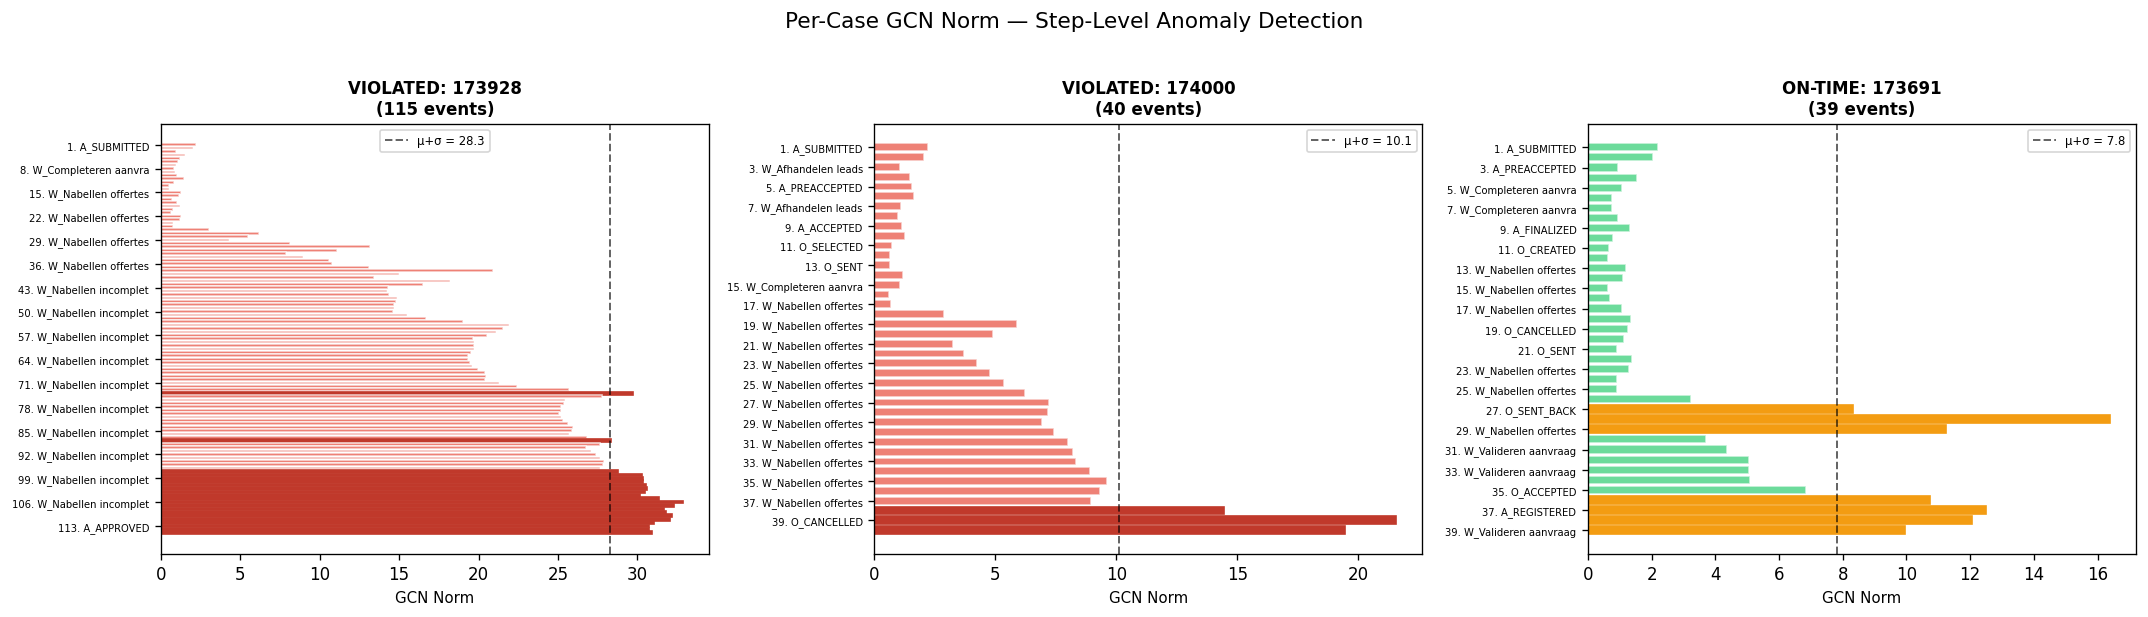


  SUMMARY TABLE FOR SLIDE (top anomalous steps per case)

Case 173928 (Vi phạm):
 Step                       Activity  Wait (days)  GCN Norm
  106 W_Nabellen incomplete dossiers         0.01    32.842
  107 W_Nabellen incomplete dossiers         0.20    32.268
  110           W_Valideren aanvraag         0.73    32.148
  111                     O_ACCEPTED         0.01    32.070
  109 W_Nabellen incomplete dossiers         0.00    31.772

Case 174000 (Vi phạm):
 Step            Activity  Wait (days)  GCN Norm
   39         O_CANCELLED         0.00    21.561
   40         A_CANCELLED         0.00    19.456
   38 W_Nabellen offertes         9.62    14.433
   35 W_Nabellen offertes         0.00     9.603
   36 W_Nabellen offertes         0.20     9.329

Case 173691 (Đúng hạn):
 Step             Activity  Wait (days)  GCN Norm
   28 W_Valideren aanvraag          0.0    16.389
   37         A_REGISTERED          0.0    12.507
   38          A_ACTIVATED          0.0    12.063
   29  W_Nabell

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# Use Case 3 — Per-Case GCN Norm: Step-level anomaly detection
# For each demo case (173928, 174000, 173691), compute the GCN Norm at
# every event step to pinpoint which specific steps are abnormal.
# ══════════════════════════════════════════════════════════════════════════

def compute_per_step_gcn_norm(case_df, model, activity_idx, norm_stats, device):
    """Compute GCN Norm for each event step in a single case."""
    n_act = len(activity_idx)
    case_df = case_df.sort_values("timestamp").reset_index(drop=True)
    n = len(case_df)
    acts = case_df["activity"].values
    ts = case_df["timestamp"].values
    t0 = ts[0]

    features = np.zeros((n, n_act + 2), dtype=np.float32)
    for i in range(n):
        features[i, activity_idx.get(acts[i], 0)] = 1.0
        features[i, n_act]     = (ts[i] - t0) / np.timedelta64(1, "D")
        features[i, n_act + 1] = (ts[i] - ts[i - 1]) / np.timedelta64(1, "D") if i > 0 else 0.0

    x = torch.from_numpy(features)
    x[:, -2] = (x[:, -2] - norm_stats["t_start_mean"]) / norm_stats["t_start_std"]
    x[:, -1] = (x[:, -1] - norm_stats["t_prev_mean"])  / norm_stats["t_prev_std"]

    edge_index = torch.tensor([list(range(n - 1)), list(range(1, n))], dtype=torch.long) if n > 1 else torch.zeros((2, 0), dtype=torch.long)

    x = x.to(device)
    edge_index = edge_index.to(device)

    model.eval()
    with torch.no_grad():
        h = F.relu(model.conv1(x, edge_index))
        h = F.relu(model.conv2(h, edge_index))
        norms = h.norm(dim=1).cpu().numpy()

    rows = []
    for i in range(n):
        wait_days = (ts[i] - ts[i - 1]) / np.timedelta64(1, "D") if i > 0 else 0.0
        rows.append({
            "Step": i + 1,
            "Activity": acts[i],
            "Wait (days)": round(float(wait_days), 2),
            "GCN Norm": round(float(norms[i]), 3),
        })
    return pd.DataFrame(rows)


demo_case_ids = [
    ("173928", 1),
    ("174000", 1),
    ("173691", 0),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), squeeze=False)

for col, (cid, true_label) in enumerate(demo_case_ids):
    cdf = case_groups[cid]
    df_norm = compute_per_step_gcn_norm(cdf, model, activity_idx, NORM_STATS, DEVICE)

    label_str = "VIOLATED" if true_label == 1 else "ON-TIME"
    color = "#e74c3c" if true_label == 1 else "#2ecc71"

    ax = axes[0][col]
    bars = ax.barh(range(len(df_norm)), df_norm["GCN Norm"], color=color, alpha=0.7, edgecolor="white")

    mean_norm = df_norm["GCN Norm"].mean()
    threshold = mean_norm + df_norm["GCN Norm"].std()
    ax.axvline(threshold, color="black", ls="--", lw=1.2, alpha=0.6, label=f"μ+σ = {threshold:.1f}")

    for i, row in df_norm.iterrows():
        if row["GCN Norm"] > threshold:
            bars[i].set_color("#c0392b" if true_label == 1 else "#f39c12")
            bars[i].set_alpha(1.0)

    short_labels = [f"{r['Step']}. {r['Activity'][:20]}" for _, r in df_norm.iterrows()]
    step = max(1, len(short_labels) // 15)
    ticks = list(range(0, len(short_labels), step))
    ax.set_yticks(ticks)
    ax.set_yticklabels([short_labels[i] for i in ticks], fontsize=6)
    ax.invert_yaxis()
    ax.set_xlabel("GCN Norm", fontsize=9)
    ax.set_title(f"{label_str}: {cid}\n({len(df_norm)} events)", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)

    # Print top anomalous steps
    print(f"\n{'='*60}")
    print(f"Case {cid} ({label_str}, {len(df_norm)} events)")
    print(f"  Mean GCN Norm: {mean_norm:.3f} | Threshold (μ+σ): {threshold:.3f}")
    print(f"{'='*60}")
    anomalies = df_norm[df_norm["GCN Norm"] > threshold].sort_values("GCN Norm", ascending=False)
    if len(anomalies) > 0:
        print(f"  ⚠ {len(anomalies)} anomalous steps (above threshold):")
        print(anomalies.to_string(index=False))
    else:
        print("  ✅ No anomalous steps detected")

plt.suptitle("Per-Case GCN Norm — Step-Level Anomaly Detection", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table for slide ──
print("\n" + "="*70)
print("  SUMMARY TABLE FOR SLIDE (top anomalous steps per case)")
print("="*70)
for cid, true_label in demo_case_ids:
    cdf = case_groups[cid]
    df_norm = compute_per_step_gcn_norm(cdf, model, activity_idx, NORM_STATS, DEVICE)
    label_str = "Vi phạm" if true_label == 1 else "Đúng hạn"
    threshold = df_norm["GCN Norm"].mean() + df_norm["GCN Norm"].std()
    top5 = df_norm.nlargest(5, "GCN Norm")
    print(f"\nCase {cid} ({label_str}):")
    print(top5[["Step", "Activity", "Wait (days)", "GCN Norm"]].to_string(index=False))

---
## Phase 5 — Export Artifacts

In [19]:
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1 — Node features (export from full graphs, not prefix-augmented)
node_rows = []
idx_to_act = {v: k for k, v in activity_idx.items()}
for g in full_graph_list:
    feat_np = g.x.numpy()
    for i in range(feat_np.shape[0]):
        node_rows.append({
            "case_id": g.case_id, "node_idx": i, "activity": g.activities[i],
            "time_since_start_d": float(feat_np[i, -2]),
            "time_since_prev_d": float(feat_np[i, -1]),
        })
pd.DataFrame(node_rows).to_csv(f"{OUTPUT_DIR}/node_embedding.csv", index=False)

# 2 — Edges
edge_rows = []
for g in full_graph_list:
    for j in range(g.edge_index.shape[1]):
        edge_rows.append({
            "case_id": g.case_id,
            "src": g.edge_index[0, j].item(),
            "dst": g.edge_index[1, j].item(),
        })
pd.DataFrame(edge_rows).to_csv(f"{OUTPUT_DIR}/edge.csv", index=False)

# 3 — Graph-level embeddings (test set)
emb_df = pd.DataFrame(embeddings, columns=[f"dim_{i}" for i in range(embeddings.shape[1])])
emb_df["label"] = emb_labels
emb_df.to_csv(f"{OUTPUT_DIR}/graph_embeddings.csv", index=False)

# 4 — Predictions
result_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "y_prob": y_prob})
result_df.to_csv(f"{OUTPUT_DIR}/result.csv", index=False)

# 5 — Model weights
torch.save(model.state_dict(), f"{OUTPUT_DIR}/sla_gcn_model.pt")

# 6 — Metrics summary
pd.DataFrame([metrics]).to_csv(f"{OUTPUT_DIR}/metrics_summary.csv", index=False)

print("\u2705 Exported artifacts:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f"   {OUTPUT_DIR}/{f:<30s}  {sz:>8.1f} KB")

✅ Exported artifacts:
   output/edge.csv                          2993.4 KB
   output/graph_embeddings.csv              7891.3 KB
   output/metrics_summary.csv                  0.2 KB
   output/node_embedding.csv               17584.2 KB
   output/result.csv                          64.5 KB
   output/sla_gcn_model.pt                    49.2 KB


---
## Conclusion

### Results Summary

The GCN model learns to distinguish SLA-violating cases from on-time cases by encoding each process instance as a **directed graph** and applying graph convolutions that capture both **structural** (activity sequence, rework loops) and **temporal** (timing gaps, delays) patterns.

### Key Takeaways

- **Graph representation** preserves the topology of business process execution (unlike flat feature vectors)
- **Class-weighted loss** handles the natural imbalance between on-time and violated cases
- **Early stopping** on validation F1 prevents overfitting and ensures generalization
- **Early warning** capability: the model flags risk on *partial* (in-progress) cases before completion
- **Bottleneck detection** identifies which activities correlate most with SLA breaches
- **Full reproducibility**: all seeds are fixed for deterministic results across CPU and CUDA

### Possible Extensions

| Enhancement | Description |
|---|---|
| **GAT (Graph Attention)** | Attention-based convolutions for built-in interpretability |
| **Temporal GNN** | Add LSTM/GRU layers to capture sequential dynamics |
| **Multi-SLA checkpoints** | Predict violations at multiple intermediate milestones |
| **Online learning** | Incrementally update the model as new cases stream in |

---
*Pipeline: `Event Log → Case Graph → GNN → SLA Prediction → Business Action`*